In [ ]:
from fasthtml.common import *
from fasthtml.jupyter import *
from my_blog import core_v5
from my_blog.admin_v1 import (register_admin_routes, post_edit, save_post, replace_iframe, replace_strava, post, 
    load_post, edit_layout, delete_post, download_post)
from my_blog.core_v5 import *
from monsterui.all import *
import re

In [ ]:
# Initialize and run the app
app, state = create_app()
core_v5.state = state
register_routes(app)  # Register all @route decorated handlers
register_admin_routes(app, state) # Register all @route decorated handlers and pass state varable to the module
# srv = JupyUvi(app)  # For notebook testingb

Are they the same class? True


In [ ]:
srv = JupyUvi(app)

In [ ]:
slug_list = state.pdb.q("""SELECT p.slug FROM posts p ORDER BY p.created""")
slug_list = [slug['slug'] for slug in slug_list]

In [ ]:
state.pdb

<Database <apsw.Connection "/app/data/my-blog/data/posts.db" at 0x730338acbb00>>

I dont see why I am getting this error when I pass state into admin_v1 when the the module routes are registered

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The problem is in your SQL query on line 122 of `admin_v1.py`. You're using `_state.tags_t` and `_state.post_tag_t` as **literal text inside the SQL string**, but those are Python variable names, not SQL table names. SQLite sees `_state.tags_t` and thinks you're referring to a table called `tags_t` in a schema called `_state`.

As you can see from your test, `state.tags_t` is `<Table tags (id, name)>` — the actual table name is just `tags`.

You need to use the real table names in your SQL, e.g. `tags` and `post_tags` (or whatever `post_tag_t` maps to). Want to check what `state.post_tag_t` resolves to as well?

Can you use dialogue tools to check why the user.role is not working above.  This comes from the fasthtml-auth library

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me look at the relevant code to understand what's happening.

<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[320, 375])</summary>

```json
{
  "id": "toolu_01NdVX2VfK65E8iaMc2Gokp7",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[320, 375]"
    }
  },
  "result": "<TRUNCATED>\u2026return Span(name, cls=\"text-xs px-2 py-1 rounded bg-muted\")\n   321 \u2502 \n   322 \u2502 # %% ../nbs/05_blog_v5.ipynb #b0de129c\n   323 \u2502 @route\n   324 \u2502 def blog(htmx, req, tags:str=None):\n   325 \u2502     # selected is a SET of the name of the selected tags\n   326 \u2502     selected = {unquote(t.strip()) for t in (tags or '').split(',') if t.strip()}\n   327 \u2502     filtered = get_posts(tags=selected)\n   328 \u2502     tag_filter_div = tag_filter(selected)\n   329 \u2502     items = [post_card(p, req) for p in filtered]\n   330 \u2502     post_content = Div(*items, cls=\"space-y-2\", id=\"posts-list\") if items else P(\"No posts yet.\", cls=\"text-muted-foreground\", id=\"posts-list\")\n   331 \u2502     if htmx and htmx.target == \"posts-list\":\n   332 \u2502         tag_filter_div.attrs['hx-swap-oob'] = 'true'\n   333 \u2502         return post_content, tag_filter_div\n   334 \u2502     return layout(H2(\"Blog\"), tag_filter_div, Divider(cls=('my-2')), post_content, title=\"Blog\", htmx=htmx)\n   335 \u2502 \n   336 \u2502 # %% ../nbs/05_blog_v5.ipyn\u2026</TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog')</summary>

```json
{
  "id": "toolu_01SUK1Pyg5bLJuYmdoLynMXt",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog"
    }
  },
  "result": "Directory contents of /app/data/my-blog/my_blog:\n/app/data/my-blog/my_blog/blog.py (1.6k)\n/app/data/my-blog/my_blog/core.py (0.6k)\n/app/data/my-blog/my_blog/__init__.py (0.0k)\n/app/data/my-blog/my_blog/core_bu.py (14.9k)\n/app/data/my-blog/my_blog/_modidx.py (14.1k)\n/app/data/my-blog/my_blog/admin_v1.py (6.7k)\n/app/data/my-blog/my_blog/core_v2.py (20.1k)\n/app/data/my-blog/my_blog/core2.py (1.8k)\n/app/data/my-blog/my_blog/config.py (1.9k)\n/app/data/my-blog/my_blog/core_v5.py (25.3k)"
}
```

</details>



🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The problem is on line 362 — when no user is logged in, `req.scope.get('user')` returns `None`, and then calling `.role` on `None` crashes.

The fix is simple — you just need to handle the case where `user` is `None`:

```python
is_admin = user and user.role == 'admin'
```

This way `is_admin` will be `False` when there's no logged-in user, instead of raising an `AttributeError`.

That will solve the error but the user should not be none or they would not have access to the admin/edit route (which this logged in user does). 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good point — the user is authenticated (they can access admin routes), so the issue is likely how `user` is being passed or retrieved in `post_card`. Let me check that function:

<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[336, 380])</summary>

```json
{
  "id": "toolu_01WYSax1HfH1CjvVsNC9UmCU",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[336, 380]"
    }
  },
  "result": "<TRUNCATED>\u2026 ../nbs/05_blog_v5.ipynb #4df85229\n   337 \u2502 def get_post_image(p):\n   338 \u2502     # check post content for image (/static/image/post_images/slug/*)\n   339 \u2502     # If image found then load a thumbnail of it\n   340 \u2502     img_ptn = r\"!\\[\\[([^|\\]]+?)(?:\\|[^\\]]+)?\\]\\]\"\n   341 \u2502     imgs = re.findall(img_ptn,p[\"content\"])\n   342 \u2502     img = imgs[0] if len(imgs)>0 else None\n   343 \u2502     if img:\n   344 \u2502         img_path = Path(img)\n   345 \u2502         slug = get_slug(p['title'])\n   346 \u2502         img_path = Path(config.POST_IMAGE_DIR) / Path(slug) / img_path\n   347 \u2502         return img_path\n   348 \u2502     else:\n   349 \u2502         return None\n   350 \u2502 \n   351 \u2502 # %% ../nbs/05_blog_v5.ipynb #2de6b8cf\n   352 \u2502 def post_card(p, req):\n   353 \u2502     \"\"\"Create a card to view a summary of the post including\n   354 \u2502     - Title (linked)\n   355 \u2502     - Excerpt\n   356 \u2502     - possible thumbnail image if one is in the post, to the right of the text\n   357 \u2502     - Date\n   358 \u2502     - Tags as sma\u2026</TRUNCATED>"
}
```

</details>

Now let me check how the app and auth middleware are set up — specifically how `user` gets into `req.scope`:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…/app/data/my-blog/my_blog/core…</…>')</summary>

```json
{
  "id": "toolu_012yeaSHUHzAcaeQqkACQmy2",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"user\" /app/data/my-blog/my_blog/core_v5.py --max-count=30"
    }
  },
  "result": "32:    db: Database # For managing users and authorising access\n93:    admin = auth.get_user(config.ADMIN_USERNAME)\n94:    if admin and config.ADMIN_PASSWORD: auth.user_repo.update(admin.id, password=config.ADMIN_PASSWORD, email=config.ADMIN_EMAIL)\n361:    user = req.scope.get('user')\n362:    is_admin = user.role == 'admin'      # 'user', 'manager', or 'admin'"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…beforeware\|Beforeware\|middle…</…>')</summary>

```json
{
  "id": "toolu_01Vkff1orBCby95FCNxp5BAa",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"auth\\|beforeware\\|Beforeware\\|middleware\\|scope.*user\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "No output"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…_app\|fast_app\|FastHTML\|auth…</…>')</summary>

```json
{
  "id": "toolu_01J1GDGkvVmKmnb7UgW3zPmK",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"create_app\\|fast_app\\|FastHTML\\|auth\" /app/data/my-blog/my_blog/core_v5.py --max-count=30"
    }
  },
  "result": "No output"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[1, 100])</summary>

```json
{
  "id": "toolu_01228L1Q1JWZFHtYHuxNPd6U",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[1, 100]"
    }
  },
  "result": "<TRUNCATED>\u2026GENERATED! DO NOT EDIT! File to edit: ../nbs/05_blog_v5.ipynb.\n     2 \u2502 \n     3 \u2502 # %% auto #0\n     4 \u2502 __all__ = ['AppState', 'create_database_tables', 'create_post_database', 'create_app', 'route', 'register_routes', 'intro',\n     5 \u2502            'hx_attrs', 'hx_link', 'navbar', 'x_icon', 'social_link', 'footer', 'layout', 'slug_exists', 'get_slug',\n     6 \u2502            'add_post', 'blogpost', 'index', 'get_tags', 'get_post_tags', 'get_posts', 'tag_pill', 'tag_filter',\n     7 \u2502            'tag_badge', 'blog', 'get_post_image', 'post_card', 'process_upload', 'get', 'post', 'rewrite_image_paths',\n     8 \u2502            'convert_obsidian_images', 'load_md_file', 'about_content', 'about', 'strava_embed',\n     9 \u2502            'process_strava_embeddings', 'process_obsidian_images', 'EnhancedRenderer']\n    10 \u2502 \n    11 \u2502 # %% ../nbs/05_blog_v5.ipynb #6a381e96\n    12 \u2502 from fastlite import Database\n    13 \u2502 from pathlib import Path\n    14 \u2502 from datetime import datetime, timede\u2026</TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[100, 120])</summary>

```json
{
  "id": "toolu_01TorBtWUTTetNF5YjRYgix4",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[100, 120]"
    }
  },
  "result": "100 \u2502         secret_key=config.SECRET_KEY,\n   101 \u2502         hdrs=hdrs,\n   102 \u2502         exts='ws'  # Enable WebSocket support\n   103 \u2502     )\n   104 \u2502     config.STATIC_DIR.mkdir(parents=True, exist_ok=True)\n   105 \u2502     app.mount(\"/static\", StaticFiles(directory=str(config.STATIC_DIR)), name=\"static\")\n   106 \u2502     auth.register_routes(app, include_admin=True)\n   107 \u2502     state = AppState(\n   108 \u2502         pdb=pdb,\n   109 \u2502         posts_t=posts_t,\n   110 \u2502         tags_t=tags_t,\n   111 \u2502         post_tags_t=post_tags_t,\n   112 \u2502         auth=auth,\n   113 \u2502         db=db\n   114 \u2502     )\n   115 \u2502     return app, state\n   116 \u2502 \n   117 \u2502 # %% ../nbs/05_blog_v5.ipynb #962ff0b2\n   118 \u2502 # Route collection for deferred registration\n   119 \u2502 _routes = []\n   120 \u2502"
}
```

</details>

Now I can see the issue. The `blog` route matches `/blog.*` in `public_paths` (line 87), so the auth beforeware **doesn't require authentication** for that route. That means when an unauthenticated visitor hits `/blog`, the beforeware doesn't populate `req.scope['user']`, so it's `None`.

The `post_card` function is called from `blog`, which is a public route — so `user` can legitimately be `None` there even though an *admin* user would also see it when logged in.

So actually, the defensive check `is_admin = user and user.role == 'admin'` is the right fix here. The blog page needs to work for both anonymous visitors and logged-in admins. Does that make sense?

Just for clarification, the user.role would still raise an error but if the user is is_admin and user is none then does this mean that the second test is not carried out

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠

Exactly right! This is called **short-circuit evaluation** in Python.

With `is_admin = user and user.role == 'admin'`:

- Python evaluates `user` first
- If `user` is `None` (which is falsy), Python **stops immediately** and returns `None` — it never evaluates `user.role == 'admin'`
- Only if `user` is truthy (i.e. an actual user object) does it proceed to check `.role == 'admin'`

So the `AttributeError` is avoided because Python never reaches `user.role` when `user` is `None`.

OK but in this case the user is logged in and I need to trigger the display of the button.  If this route is not returning the user then it will never be able to set the buttons to display

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Ah, I see — you want the blog page to show admin buttons when an admin *is* logged in, but still be accessible to anonymous visitors. The problem is likely that the auth beforeware skips public routes entirely, so it never even *tries* to populate the user.

Let me check how the auth beforeware handles public paths:

<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[70, 100])</summary>

```json
{
  "id": "toolu_01JhJ86rAFLUXhCbDZLt5sMv",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[70, 100]"
    }
  },
  "result": "<TRUNCATED>\u2026reate_database_tables(pdb)\n    71 \u2502     return pdb\n    72 \u2502 \n    73 \u2502 # %% ../nbs/05_blog_v5.ipynb #6be13b13\n    74 \u2502 def create_app():\n    75 \u2502     # Create databases and apps, return these within and AppState class.\n    76 \u2502     # Once created then create the server with srv = serve()\n    77 \u2502     # Add the routes with rt = app.route\n    78 \u2502     pdb = create_post_database(config.POSTS_DB_PATH)\n    79 \u2502     posts_t = pdb.t.posts\n    80 \u2502     tags_t = pdb.t.tags\n    81 \u2502     post_tags_t = pdb.t.post_tags\n    82 \u2502     # Initialize auth database\n    83 \u2502     auth = AuthManager(\n    84 \u2502         db_path=str(config.USERS_DB_PATH),\n    85 \u2502         config={\n    86 \u2502             'allow_registration': config.ALLOW_REGISTRATION,\n    87 \u2502             'public_paths': ['/', '/about', r'/blog.*', r'/post.*'],  # Let anybody see the site apart from the admin and auth routes\n    88 \u2502             'login_path': '/auth/login',\n    89 \u2502         }\n    90 \u2502     )\n    91 \u2502     db = aut\u2026</TRUNCATED>"
}
```

</details>

Now let me check what `AuthManager.create_beforeware` does — it's from `fasthtml-auth`:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…e_beforeware\|def beforeware\|…</…>')</summary>

```json
{
  "id": "toolu_015Mtc1mCks6qhZbE6SyfuGC",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-rn \"create_beforeware\\|def beforeware\\|def before_\" /app/data --include=\"*.py\" -l"
    }
  },
  "result": "error: Found argument '--include' which wasn't expected, or isn't valid in this context\n\tDid you mean --include-zero?\n\nUSAGE:\n    \n    rg [OPTIONS] PATTERN [PATH ...]\n    rg [OPTIONS] -e PATTERN ... [PATH ...]\n    rg [OPTIONS] -f PATTERNFILE ... [PATH ...]\n    rg [OPTIONS] --files [PATH ...]\n    rg [OPTIONS] --type-list\n    command | rg [OPTIONS] PATTERN\n    rg [OPTIONS] --help\n    rg [OPTIONS] --version\n\nFor more information try --help"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-rn "create_beforeware" /app/data -g "*.py"')</summary>

```json
{
  "id": "toolu_01AjuaEBQUtymdEpZbWCkRUN",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-rn \"create_beforeware\" /app/data -g \"*.py\""
    }
  },
  "result": "/app/data/my-blog/my_blog/core_v5.py:95:    beforeware = auth.n()\n/app/data/my-blog/my_blog/core_v2.py:91:    beforeware = auth.n()\n/app/data/my-blog/my_blog/core_bu.py:80:    beforeware = auth.n()"
}
```

</details>



<details class='tool-usage-details'>
<summary>pyrun(code='<…>…le("fasthtml_auth")\nsymsrc("fa…</…>')</summary>

```json
{
  "id": "toolu_013ajWmGoMv9Mg35re36rVcA",
  "call": {
    "function": "pyrun",
    "arguments": {
      "code": "importmodule(\"fasthtml_auth\")\nsymsrc(\"fasthtml_auth.AuthManager.create_beforeware\")"
    }
  },
  "result": "File: /app/data/.local/lib/python3.12/site-packages/fasthtml_auth/manager.py\n\n    def create_beforeware(self, additional_public_paths=None):\n        return self.middleware.create_beforeware(additional_public_paths)"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='fasthtml_auth.AuthMiddleware.create_beforeware')</summary>

```json
{
  "id": "toolu_0191Afn5BfnXpfigCzutXDCz",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fasthtml_auth.AuthMiddleware.create_beforeware"
    }
  },
  "result": "<TRUNCATED>\u2026-----------------------------------------------------------------\nAttributeError                            Traceback (most recent call last)\nCell In[23], line 1\n----> 1 await maybe_await(symsrc(sym='fasthtml_auth.AuthMiddleware.create_beforeware'))\n\nFile /usr/local/lib/python3.12/site-packages/toolslm/inspecttools.py:96, in symsrc(sym)\n     84 @llmtool\n     85 def symsrc(\n     86     sym: str  # Dotted symbol path (e.g `Interval` or `sympy.sets.sets.Interval`) or \"_last\" for previous result\n     87 ):\n     88     \"\"\"Get the source code for a symbol.\n     89 \n     90     Examples:\n   (...)     94     - `symsrc(\"_last\")` -> source of object from previous tool call\n     95     - For dispatchers or registries of callables: `symnth(\"module.dispatcher.funcs\", n) then symsrc(\"_last\")`\"\"\"\n---> 96     try: obj = resolve(sym)\n     97     except SymbolNotFound as e: return str(e)\n     98     if isinstance(obj, type) or callable(obj): pass\n\nFile /usr/local/lib/python3.12/site-\u2026</TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…reate_beforeware" /app/data/.l…</…>')</summary>

```json
{
  "id": "toolu_01QAPFbVzhAap7C8nY6gkaTn",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-rn \"def create_beforeware\" /app/data/.local/lib/python3.12/site-packages/fasthtml_auth/ -g \"*.py\""
    }
  },
  "result": "/app/data/.local/lib/python3.12/site-packages/fasthtml_auth/middleware.py:29:    n(self, additional_public_paths=None):\n/app/data/.local/lib/python3.12/site-packages/fasthtml_auth/manager.py:49:    n(self, additional_public_paths=None):"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='<…>….local/lib/python3.12/site-pac…</…>', nums=True)</summary>

```json
{
  "id": "toolu_01X9uy4LQKXz79eazkTdt4Ka",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/.local/lib/python3.12/site-packages/fasthtml_auth/middleware.py",
      "nums": "True"
    }
  },
  "result": "<TRUNCATED>\u2026asthtml.common import *\n     2 \u2502 import inspect\n     3 \u2502 from typing import Optional, List, Any, Callable\n     4 \u2502 \n     5 \u2502 class AuthBeforeware:\n     6 \u2502     \"\"\"Authentication middleware for fastHTML\"\"\"\n     7 \u2502 \n     8 \u2502     def __init__(self, auth_manager, config=None):\n     9 \u2502         self.auth_manager = auth_manager\n    10 \u2502         self.config = config or {}\n    11 \u2502 \n    12 \u2502         # Configure paths\n    13 \u2502         login_path = '/auth/login'\n    14 \u2502         self.login_path = self.config.get(\"login_path\", login_path)\n    15 \u2502         self.public_paths = self.config.get(\"public_paths\", [])\n    16 \u2502         # Static files patterns\n    17 \u2502         self.static_patterns = [\n    18 \u2502             r'/favicon\\.ico',\n    19 \u2502             r'/static/.*',\n    20 \u2502             r'.*\\.css',\n    21 \u2502             r'.*\\.js',\n    22 \u2502             r'.*\\.png',\n    23 \u2502             r'.*\\.jpg',\n    24 \u2502             r'.*\\.jpeg',\n    25 \u2502             r'.*\\.gif',\n    26 \u2502        \u2026</TRUNCATED>"
}
```

</details>

There it is. Looking at lines 55-68 of the middleware:

- When a public path is hit, `auth_check` is **skipped entirely** (that's how FastHTML's `Beforeware` with `skip=` works)
- `req.scope['user']` is only set on line 68 — inside `auth_check`
- So for public routes like `/blog`, the user is **never populated**, even if the visitor has a valid session

The fix needs to happen in your `post_card` function, not the middleware. Since `/blog` is public, you need to handle both cases. You could retrieve the user from the session yourself:

```python
user = req.scope.get('user')
is_admin = user and user.role == 'admin'
```

This is the correct approach — the blog route *should* be public, and `post_card` just needs to gracefully handle anonymous visitors by not showing admin buttons. When an admin visits, the beforeware won't run (it's skipped), so you'd either need:

1. The simple `user and user.role` guard (quickest fix), or
2. Manually check the session in `post_card` to retrieve the user for public routes

Which approach would you prefer?

Lets load the user information from post_card

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good idea. Let me check how the middleware retrieves the user from the session so you can do the same thing in `post_card`:

<details class='tool-usage-details'>
<summary>view(path='<…>….local/lib/python3.12/site-pac…</…>', nums=True, view_range=[55, 75])</summary>

```json
{
  "id": "toolu_01A5LmDQRjwY558JXirM6pLr",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/.local/lib/python3.12/site-packages/fasthtml_auth/middleware.py",
      "nums": "True",
      "view_range": "[55, 75]"
    }
  },
  "result": "<TRUNCATED>\u2026       if not auth_username:\n    56 \u2502                 # No auth, redirect to login\n    57 \u2502                 return RedirectResponse(self.login_path, status_code=303)\n    58 \u2502             \n    59 \u2502             # Verify user is still valid\n    60 \u2502             user = self.auth_manager.get_user(auth_username)\n    61 \u2502             if not user or not user.active:\n    62 \u2502                 # Invalid user, clear session and redirect\n    63 \u2502                 sess.clear()\n    64 \u2502                 return RedirectResponse(self.login_path, status_code=303)\n    65 \u2502             \n    66 \u2502             # Add user info to request scope for route handlers\n    67 \u2502             req.scope['auth'] = auth_username\n    68 \u2502             req.scope['user'] = user\n    69 \u2502             req.scope['user.id'] = user.id\n    70 \u2502             req.scope['user_role'] = user.role\n    71 \u2502             req.scope['user_is_admin'] = user.role == \"admin\"\n    72 \u2502 \n    73 \u2502         # Return configured Beforewa\u2026</TRUNCATED>"
}
```

</details>

So the middleware gets the username from the session (line 54 area), then calls `auth_manager.get_user(auth_username)` on line 60. 

In your `post_card`, you have access to `req` — you can do the same: check the session for the username, and if present, look up the user. Something like:

```python
sess = req.scope.get('session', {})
auth_username = sess.get('auth')
user = state.auth.get_user(auth_username) if auth_username else None
is_admin = user and user.role == 'admin'
```

You'll need access to `state` (or just `state.auth`) in `post_card` to call `get_user`. How are you currently passing `state` into that function?

state is set as a module level variable

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Perfect, so you can use `state.auth.get_user()` directly in `post_card`. You'd replace the current lines:

```python
user = req.scope.get('user')
is_admin = user.role == 'admin'
```

with:

```python
sess = req.scope.get('session', {})
auth_username = sess.get('auth')
user = state.auth.get_user(auth_username) if auth_username else None
is_admin = user and user.role == 'admin'
```

Want to go ahead and make that change?

Lets look at option 1.  How would I then make state available to the functions within the admin_v1 file?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The trick is to define your route handler functions *inside* `register_admin_routes`. That way they form a **closure** over the `state` parameter — they "remember" it automatically.

So the structure in `admin_v1.py` would look something like:

```python
def register_admin_routes(app, state):
    @app.get('/admin/edit/{slug}')
    def post_edit(slug):
        p = load_post(state, slug)  # state is available here via closure
        ...
```

Any function defined inside `register_admin_routes` will have access to `state` without needing globals. Does that make sense? Would you like to try restructuring your file that way?

But that will mean that the register_admin_routes will become very large and messy. Not sure I like that

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good point! A nice middle ground: set a **module-level variable** during registration, then your existing functions can stay as they are.

```python
# admin_v1.py
_state = None

def register_admin_routes(app, state):
    global _state
    _state = state
```

Then your existing functions just use `_state` instead of `state`. It's essentially what you're already doing with `core_v5.state = state`, but contained within the module itself — cleaner and more self-contained.

Does that feel like a better fit?

In [ ]:
state.posts_t()

[create_database_tables.<locals>.Posts(id=1, title='A Journey to Lake Maggiore', slug='a-journey-to-lake-maggiore', content='In the summer of 2025 we took our motorhome to the Italian Lakes to meet up with our two daughters and their families.  They flew to Milan and hired motorhomes there, and we planned to meet at Lake Maggiore.\n\nOur route is shown below.\n\n<iframe src="https://www.google.com/maps/d/embed?mid=1NXlWhw7ZUcEQ_hGaXVAuuPz4DnGN_wQ&hl=en&ehbc=2E312F" width="640" height="480"></iframe>\n\nIn brief after taking a ferry to Calais we then went Belgium before turning south at Charleroi and heading south back into France.  We took this route to avoid tolls and to follow a more rural route through France.  After that we went through Luxembourg into Germany and then east to the Rhine valley, where we stayed for a couple of nights at the campsite attached to the Speyer Technical Museam.  We then headed into the Black Forest and spent three nights there.  The next step was to head

In [ ]:
state.tags_t()

[create_database_tables.<locals>.Tags(id=1, name='motorhome'),
 create_database_tables.<locals>.Tags(id=2, name='cycling')]

In [ ]:
state.post_tags_t()

[create_database_tables.<locals>.PostTags(post_id=2, tag_id=2)]

In [ ]:
from my_blog.core_v5 import get_post_image

In [ ]:
post = {'id': 1}
content = 'In the summer of 2025 we took our motorhome to the Italian Lakes to meet up with our two daughters and their families.  They flew to Milan and hired motorhomes there, and we planned to meet at Lake Maggiore.\n\nOur route is shown below.\n\n<iframe src="https://www.google.com/maps/d/embed?mid=1NXlWhw7ZUcEQ_hGaXVAuuPz4DnGN_wQ&hl=en&ehbc=2E312F" width="640" height="480"></iframe>\nIn brief after taking a ferry to Calais we then went Belgium before turning south at Charleroi and heading south back into France.  We took this route to avoid tolls and to follow a more rural route through France.  After that we went through Luxembourg into Germany and then east to the Rhine valley, where we stayed for a couple of nights at the campsite attached to the Speyer Technical Museam.  We then headed into the Black Forest and spent three nights there.  The next step was to head south into Switzerland and the Gottard tunnet.  We stayed for a night at an Aire just before reaching the tunnel at a lovely location Campingplatz Trendcamping Wolfach im Schwarzwald.  The next day we went through the tunnel and into Italy, where we made our way around Lake Maggiore on the western shore.  Breaking the drive down like this made it a fun trip and not too ardious.  I will briefly elaborate on the places we stayed in case anybody else would like to make a similar journey.\n\n#### Vouziers\n\nOur first stop was at a lovely small Aire in Vouziers.  This was free, provided water and waste facilities and was a short walk to the city centre where there were plenty of places to have something to eat and drink.  The central square and the town hall are very nice, thought a lot of work was going on in the square whilst we were there.  \n![[aire_in_vouziers.jpeg|250|left]]\n\n![[vouziers_centre.jpeg|250|right]]\nIn the morning we brought some pastries from a Boulangerie (there were three there to chose from).\n\nIt looked as though there were also some nice walks along the river but we didn\'t have time to do any of those.\n\n#### Speyer\n\nWe had wanted to go to the Technical Museam of Speyer for some time (since we saw people walking on the wing of a real 747 there whilst on a Rhine criuse).  The museum website is [here.](https://speyer.technik-museum.d) There is a campsite attached to the museum hotel which is where we stayed.  The site was good value for money and had all of the facilities needed.  The pitches were quite tight but then we were there mainly to visit the museum and Speyer so it wasn\'t an issue.\n\nThe museum itself if well worth a visit.  It had an amazing collection of place, boats, submarines, spececraft, trains, cars and motorbikes, many of which you were able to climb into and look around.  I attach some pictures of some of the highlights below.'
post['content']=content
post['title'] ='A Journey to Lake Maggiore'


In [ ]:
get_post_image(post)

Path('static/image/post_images/a-journey-to-lake-maggiore/aire_in_vouziers.jpeg')

Can you see why the above function has not found any image urls?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me look at the `get_post_image` function source:

<details class='tool-usage-details'>
<summary>symsrc(sym='get_post_image')</summary>

```json
{
  "id": "toolu_01BDCEyQeKzD4n8FJLMjF9md",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "get_post_image"
    }
  },
  "result": "'File: /app/data/my-blog/my_blog/core_v5.py\\n\\ndef get_post_image(p):\\n    # check post content for image (/static/image/post_images/slug/*)\\n    # If image found then load a thumbnail of it\\n    img_ptn = r\"!\\\\[.*?\\\\]\\\\((/static/image/post_images/[^)]+)\\\\)\"\\n    imgs = re.findall(img_ptn,p[\"content\"])\\n    img = imgs[0] if len(imgs)>0 else None\\n    if img:\\n        img_path = Path(img)\\n        slug = get_slug(p[\\'title\\'])\\n        img_path = Path(config.POST_IMAGE_DIR) / Path(slug) / img_path\\n        return img_path\\n    else:\\n        return None\\n'"
}
```

</details>

The issue is clear — the regex pattern is looking for standard markdown image syntax `![...](url)`, but your post content uses **Obsidian-style** wiki image links like `![[aire_in_vouziers.jpeg|250|left]]`. These have a completely different format (`![[filename|size|alignment]]`) which the pattern doesn't match.

Not sure what I am meant to run but here is the function:
def get_post_image(p):
    # check post content for image (/static/image/post_images/*)
    # If image found then load a thumbnail of it
    img_ptn = r"!\[.*?\]\((/static/image/post_images/[^)]+)\)"
    imgs = re.findall(img_ptn,p["content"])
    img = imgs[0] if len(imgs)>0 else None
    if img:
        img_path = Path(img)
        img_path = config.STATIC_DIR.parent / img_path
        return img_path
    else:
        return None

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The content uses **Obsidian-style** image syntax like `![[aire_in_vouziers.jpeg|250|left]]`, but the regex pattern is looking for **standard markdown** image syntax like `![alt](/static/image/post_images/filename.jpg)`. The two formats don't match, so `re.findall` returns nothing.

Can you suggest an adaptaion to the regex.  The version of format we are using can also have options for layout and size (as you can see above, though these are optional)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Replace the pattern with this, which handles the Obsidian `![[...]]` format with optional size/layout parameters:

```python
img_ptn = r"!\[\[([^|\]]+?)(?:\|[^\]]+)?\]\]"
```

This captures just the filename, ignoring any `|250|left` style options that may follow.

Thats great, I also need to adapt the path generated to include the slug in the path name (posts are now saved under post_images/slug_name/filename)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠

```python
img_ptn = r"!\[\[([^|\]]+?)(?:\|[^\]]+)?\]\]"
imgs = re.findall(img_ptn, p["content"])
img = imgs[0] if imgs else None
if img:
    return config.STATIC_DIR.parent / 'static' / 'image' / 'post_images' / p['slug'] / img
```

In [ ]:
# Please run this:
import inspect
print(inspect.getsource(get_post_image))

def get_post_image(p):
    # check post content for image (/static/image/post_images/slug/*)
    # If image found then load a thumbnail of it
    img_ptn = r"!\[\[([^|\]]+?)(?:\|[^\]]+)?\]\]"
    imgs = re.findall(img_ptn,p["content"])
    img = imgs[0] if len(imgs)>0 else None
    if img:
        img_path = Path(img)
        slug = get_slug(p['title'])
        img_path = Path(config.POST_IMAGE_DIR) / Path(slug) / img_path
        return img_path
    else:
        return None



I intend to deploy this blog to a production server. In another application using fasthtml-auth for authentication and then fasthtml I configured the database setup and environmental variables in a .env file for the dev version, removed this file from git and created a copy which I modified for production, with appropriate secrets and database login details.  I then copied the prod version of .env to the production server outside of git, which should then stay there despite git updates. I intend to do the same here.  I am using this file to test the server but have a file app.py which I intend to use for production.  To adopt this approach I need to modify config.py to load variables from .env. I might also need to change the code in core_v5.py to initialize the database with the correct user ids etc.  Can you check the two files and suggest the changes I will need to make to impliment this

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->





🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me take a look at both files.

<details class='tool-usage-details'>
<summary>view(path='my_blog/config.py')</summary>

```json
{
  "id": "toolu_018g5knPKz6BUvqJN63Ghm4y",
  "call": {
    "function": "view",
    "arguments": {
      "path": "my_blog/config.py"
    }
  },
  "result": "'\"\"\"\\nConfiguration managment\\n\"\"\"\\nimport os\\nfrom pathlib import Path\\nfrom dotenv import load_dotenv\\n\\n# Load environment variables from .env file\\nload_dotenv()\\n\\n# ====================================\\n# Paths\\n# ====================================\\n\\nBASE_DIR = Path(__file__).parent\\nPROJECT_ROOT = BASE_DIR.parent\\nSTATIC_DIR = Path(os.environ.get(\\'STATIC_DIR\\', PROJECT_ROOT / \\'static\\'))\\nDATA_DIR = Path(os.environ.get(\\'DATA_DIR\\', BASE_DIR / \\'data\\'))\\nIMAGE_DIR = STATIC_DIR / \\'image\\'\\nPOST_IMAGE_DIR = IMAGE_DIR / \\'post_images\\'\\nTEST_DIR = Path(PROJECT_ROOT / \\'test\\')\\n\\n# Ensure data directory exists\\nDATA_DIR.mkdir(exist_ok=True)\\n# Ensure static, image and post image  directories exists\\nSTATIC_DIR.mkdir(exist_ok=True)\\nIMAGE_DIR.mkdir(exist_ok=True)\\nPOST_IMAGE_DIR.mkdir(exist_ok=True)\\n\\nUSERS_DB_NAME = os.environ.get(\\'USERS_DB_NAME\\', \\'users.db\\') \\nUSERS_DB_PATH = DATA_DIR / USERS_DB_NAME\\nPOSTS_DB_NAME = os.environ.get(\\'POSTS_DB_NAME\\', \\'posts.db\\')\\nPOS<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='my_blog/core_v5.py')</summary>

```json
{
  "id": "toolu_011CAAND9id7LpQJ96NV3cQG",
  "call": {
    "function": "view",
    "arguments": {
      "path": "my_blog/core_v5.py"
    }
  },
  "result": "'# AUTOGENERATED! DO NOT EDIT! File to edit: ../nbs/05_blog_v5.ipynb.\\n\\n# %% auto #0\\n__all__ = [\\'AppState\\', \\'create_database_tables\\', \\'create_post_database\\', \\'create_app\\', \\'route\\', \\'register_routes\\', \\'intro\\',\\n           \\'hx_attrs\\', \\'hx_link\\', \\'navbar\\', \\'x_icon\\', \\'social_link\\', \\'footer\\', \\'layout\\', \\'slug_exists\\', \\'add_post\\',\\n           \\'blogpost\\', \\'index\\', \\'get_tags\\', \\'get_post_tags\\', \\'get_posts\\', \\'tag_pill\\', \\'tag_filter\\', \\'tag_badge\\', \\'blog\\',\\n           \\'get_post_image\\', \\'post_card\\', \\'process_upload\\', \\'get\\', \\'post\\', \\'rewrite_image_paths\\',\\n           \\'convert_obsidian_images\\', \\'load_md_file\\', \\'about_content\\', \\'about\\', \\'strava_embed\\',\\n           \\'process_strava_embeddings\\', \\'process_obsidian_images\\', \\'EnhancedRenderer\\']\\n\\n# %% ../nbs/05_blog_v5.ipynb #6a381e96\\nfrom fastlite import Database\\nfrom pathlib import Path\\nfrom datetime import datetime, timedelta\\nimport my_blog.config as config\\nfrom urllib.p<TRUNCATED>"
}
```

</details>



🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good, I can see both files. Let me also check `app.py` and whether there's an existing `.env` file:

<details class='tool-usage-details'>
<summary>view(path='my_blog')</summary>

```json
{
  "id": "toolu_01VYZG9SbMFRDRicrDCzTpNd",
  "call": {
    "function": "view",
    "arguments": {
      "path": "my_blog"
    }
  },
  "result": "'Directory contents of /app/data/my-blog/my_blog:\\n/app/data/my-blog/my_blog/blog.py (1.6k)\\n/app/data/my-blog/my_blog/core.py (0.6k)\\n/app/data/my-blog/my_blog/__init__.py (0.0k)\\n/app/data/my-blog/my_blog/static \ud83d\udcc1\\n/app/data/my-blog/my_blog/core_bu.py (14.9k)\\n/app/data/my-blog/my_blog/_modidx.py (12.8k)\\n/app/data/my-blog/my_blog/core_v2.py (20.1k)\\n/app/data/my-blog/my_blog/core2.py (1.8k)\\n/app/data/my-blog/my_blog/config.py (1.9k)\\n/app/data/my-blog/my_blog/core_v5.py (24.3k)\\n/app/data/my-blog/my_blog/data \ud83d\udcc1\\n/app/data/my-blog/my_blog/static/image \ud83d\udcc1\\n/app/data/my-blog/my_blog/data/posts.db-shm (32.0k)\\n/app/data/my-blog/my_blog/data/users.db-shm (32.0k)\\n/app/data/my-blog/my_blog/data/posts.db-wal (2337.6k)\\n/app/data/my-blog/my_blog/data/users.db-wal (4.1k)\\n/app/data/my-blog/my_blog/data/posts.db (48.0k)\\n/app/data/my-blog/my_blog/data/users.db (16.0k)\\n/app/data/my-blog/my_blog/static/image/post_images \ud83d\udcc1'"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-l ".env" --hidden -g ".env*" .')</summary>

```json
{
  "id": "toolu_01EWxbPMgb4icqziuTFJejGR",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-l \".env\" --hidden -g \".env*\" ."
    }
  },
  "result": "''"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-l "app.py" -g "app.py" .')</summary>

```json
{
  "id": "toolu_012cQCNnmVtKfjZiK2cuoFwE",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-l \"app.py\" -g \"app.py\" ."
    }
  },
  "result": "''"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog')</summary>

```json
{
  "id": "toolu_01TP2X3P83dqc3UiZ9YJwWT9",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog"
    }
  },
  "result": "'Directory contents of /app/data/my-blog:\\n/app/data/my-blog/blog.py (0.3k)\\n/app/data/my-blog/settings.ini (1.0k)\\n/app/data/my-blog/static \ud83d\udcc1\\n/app/data/my-blog/nbs \ud83d\udcc1\\n/app/data/my-blog/LICENSE (11.1k)\\n/app/data/my-blog/my_blog.egg-info \ud83d\udcc1\\n/app/data/my-blog/run_blog.ipynb (7.8k)\\n/app/data/my-blog/README.md (1.3k)\\n/app/data/my-blog/pyproject.toml (0.1k)\\n/app/data/my-blog/my_blog \ud83d\udcc1\\n/app/data/my-blog/MANIFEST.in (0.1k)\\n/app/data/my-blog/test \ud83d\udcc1\\n/app/data/my-blog/setup.py (2.8k)\\n/app/data/my-blog/static/image \ud83d\udcc1\\n/app/data/my-blog/static/content \ud83d\udcc1\\n/app/data/my-blog/nbs/00_core_dup1.ipynb (212.6k)\\n/app/data/my-blog/nbs/00_core_backup_prior_to_refactor.ipynb (216.7k)\\n/app/data/my-blog/nbs/_quarto.yml (0.3k)\\n/app/data/my-blog/nbs/05_blog_v5.ipynb (748.4k)\\n/app/data/my-blog/nbs/04_blog_v4.ipynb (41.1k)\\n/app/data/my-blog/nbs/03_blog_v3.ipynb (175.0k)\\n/app/data/my-blog/nbs/00_core.ipynb (1414.9k)\\n/app/data/my-blog/nbs/01_blog_v2.ipynb (1379.4k)\\n/app/data/my-blog/nbs/styles.css (0<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/blog.py')</summary>

```json
{
  "id": "toolu_01AE6rWSitXPJkfN2MJb8weC",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/blog.py"
    }
  },
  "result": "'from fasthtml.common import FastHTML, serve\\nfrom my_blog import core_v5\\nfrom my_blog.core_v5 import *\\n\\n# Initialize and run the app\\napp, state = create_app()\\ncore_v5.state = state\\nregister_routes(app)  # Register all @route decorated handlers\\n# srv = JupyUvi(app)  # For notebook testing\\nserve(port=8000)'"
}
```

</details>



🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

OK, here's what I found:

**`config.py` is already mostly set up for `.env` loading.** It already calls `load_dotenv()` and reads all the key settings from environment variables. That's the good news.

Here's what needs attention:

**1. No `.env` file exists yet.** You'll need to create one. Here's what should go in your **dev** `.env`:

```bash
# Security
SECRET_KEY=dev-secret-key-change-me
ADMIN_USERNAME=admin
ADMIN_PASSWORD=your-dev-password
ADMIN_EMAIL=your@email.com

# Database
USERS_DB_NAME=users.db
POSTS_DB_NAME=posts.db

# App settings
DEBUG=True
ALLOW_REGISTRATION=False
HOST=0.0.0.0
PORT=8000
```

And the **prod** version would have a proper secret key, different credentials, `DEBUG=False`, etc.

**2. Admin user is never actually created.** `config.py` defines `ADMIN_USERNAME`, `ADMIN_PASSWORD`, and `ADMIN_EMAIL` — but `core_v5.py`'s `create_app()` never uses them. The `AuthManager` is initialized but there's no code to seed an initial admin user. You'll need to add something in `create_app()` (or a separate setup script) that creates the admin user if one doesn't exist yet.

**3. `blog.py` vs `app.py`.** You mentioned `app.py` for production but I only see `blog.py` at the project root. Is `blog.py` what you intend to rename, or do you plan to create a separate `app.py`?

**4. `.gitignore`.** You'll want to make sure `.env` is in your `.gitignore` so it doesn't get committed.

The biggest functional gap is item 2 — shall we tackle that first? I can look at the `AuthManager` API to see how to create/check for an admin user.

In [ ]:
state.posts_t(limit=3)

[create_database_tables.<locals>.Posts(id=1, title='A Journey to Lake Maggiore', slug='a-journey-to-lake-maggiore', content='In the summer of 2025 we took our motorhome to the Italian Lakes to meet up with our two daughters and their families.  They flew to Milan and hired motorhomes there, and we planned to meet at Lake Maggiore.\n\nOur route is shown below.\n\n<iframe src="https://www.google.com/maps/d/embed?mid=1NXlWhw7ZUcEQ_hGaXVAuuPz4DnGN_wQ&hl=en&ehbc=2E312F" width="640" height="480"></iframe>\n\nIn brief after taking a ferry to Calais we then went Belgium before turning south at Charleroi and heading south back into France.  We took this route to avoid tolls and to follow a more rural route through France.  After that we went through Luxembourg into Germany and then east to the Rhine valley, where we stayed for a couple of nights at the campsite attached to the Speyer Technical Museam.  We then headed into the Black Forest and spent three nights there.  The next step was to head

Sorry yes the file is blog.py not app.py, that was a different project. Yes lets tackle point 2

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->





🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me look at `create_app()` and the auth setup more closely.

<details class='tool-usage-details'>
<summary>rg(argstr='-n "def create_app" my_blog/core_v5.py')</summary>

```json
{
  "id": "toolu_01GZYTEHFNN7HKXW8Ct8m63B",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def create_app\" my_blog/core_v5.py"
    }
  },
  "result": "'74:def create_app():\\n'"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='my_blog/core_v5.py', nums=True, view_range=[74, 130])</summary>

```json
{
  "id": "toolu_01WqaYHvAeyH4gaYDFFp96ow",
  "call": {
    "function": "view",
    "arguments": {
      "path": "my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[74, 130]"
    }
  },
  "result": "'    74 \u2502 def create_app():\\n    75 \u2502     # Create databases and apps, return these within and AppState class.\\n    76 \u2502     # Once created then create the server with srv = serve()\\n    77 \u2502     # Add the routes with rt = app.route\\n    78 \u2502     pdb = create_post_database(config.POSTS_DB_PATH)\\n    79 \u2502     posts_t = pdb.t.posts\\n    80 \u2502     tags_t = pdb.t.tags\\n    81 \u2502     post_tags_t = pdb.t.post_tags\\n    82 \u2502     # Initialize auth database\\n    83 \u2502     auth = AuthManager(\\n    84 \u2502         db_path=str(config.USERS_DB_PATH),\\n    85 \u2502         config={\\n    86 \u2502             \\'allow_registration\\': config.ALLOW_REGISTRATION,\\n    87 \u2502             \\'public_paths\\': [],  # No public paths - all routes require auth except /auth/*\\n    88 \u2502             \\'login_path\\': \\'/auth/login\\',\\n    89 \u2502         }\\n    90 \u2502     )\\n    91 \u2502     db = auth.initialize()  \\n    92 \u2502     beforeware = auth.create_beforeware()\\n    93 \u2502     hdrs = (*Theme.blue.headers(highlightjs=True), Script(src=\"htt<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-n "ADMIN" my_blog/config.py')</summary>

```json
{
  "id": "toolu_01KumhnZ6XgzKu13rpMg1wVx",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"ADMIN\" my_blog/config.py"
    }
  },
  "result": "'51:ADMIN_USERNAME = os.getenv(\"ADMIN_USERNAME\", \"admin\")\\n52:ADMIN_PASSWORD = os.getenv(\"ADMIN_PASSWORD\")\\n53:ADMIN_EMAIL = os.getenv(\"ADMIN_EMAIL\", \"\")\\n'"
}
```

</details>

Now let me check what methods `AuthManager` provides for creating users:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "def " --type py -g "auth*" /app/data/my-blog')</summary>

```json
{
  "id": "toolu_01Q4F4v9Yj2RNQTCvQm5bbD4",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def \" --type py -g \"auth*\" /app/data/my-blog"
    }
  },
  "result": "''"
}
```

</details>



<details class='tool-usage-details'>
<summary>python(code='import fasthtml_auth\ninspect.getfile(fasthtml_auth…')</summary>

```json
{
  "id": "toolu_011kkZLLWJ2D6w3t4w5QyT9Z",
  "call": {
    "function": "python",
    "arguments": {
      "code": "import fasthtml_auth\ninspect.getfile(fasthtml_auth)"
    }
  },
  "result": "{'warnings': '`inspect` is not available in this sandbox; ask the user to add it to the available tools'}"
}
```

</details>



<details class='tool-usage-details'>
<summary>importmodule(mod='fasthtml_auth')</summary>

```json
{
  "id": "toolu_01BZkyu1m4esgKh5F4mqpSET",
  "call": {
    "function": "importmodule",
    "arguments": {
      "mod": "fasthtml_auth"
    }
  },
  "result": "None"
}
```

</details>



<details class='tool-usage-details'>
<summary>symdir(sym='fasthtml_auth.AuthManager', exclude_private=True)</summary>

```json
{
  "id": "toolu_015vFRjh4cPxYe3RpTSwfJg7",
  "call": {
    "function": "symdir",
    "arguments": {
      "sym": "fasthtml_auth.AuthManager",
      "exclude_private": "True"
    }
  },
  "result": "['create_beforeware',\n 'get_user',\n 'initialize',\n 'register_routes',\n 'require_admin',\n 'require_role']"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='fasthtml_auth.AuthManager.initialize')</summary>

```json
{
  "id": "toolu_01P77koxt4qiAU4Sao6g26Nn",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fasthtml_auth.AuthManager.initialize"
    }
  },
  "result": "'File: /app/data/.local/lib/python3.12/site-packages/fasthtml_auth/manager.py\\n\\n    def initialize(self):\\n        \"\"\"Initialise the auth system\"\"\"\\n        # Create tables\\n        self.db = self.auth_db.initialize_auth_tables()\\n\\n        # Create repo to manage users\\n        self.user_repo = UserRepository(self.db)\\n\\n        # Create default admin\\n        self._create_default_admin()\\n\\n        admin = self.get_user(\\'admin\\')\\n        (f\"Admin User class: {type(admin)}\")\\n        print(f\"Are they the same class? {type(admin) is User}\")    \\n        \\n        return self.db\\n'"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='fasthtml_auth.AuthManager._create_default_admin')</summary>

```json
{
  "id": "toolu_01BN9zNBve3VVVUovz5UXMzY",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fasthtml_auth.AuthManager._create_default_admin"
    }
  },
  "result": "'File: /app/data/.local/lib/python3.12/site-packages/fasthtml_auth/manager.py\\n\\n    def _create_default_admin(self):\\n        \"\"\"Create default admin if needed\"\"\"\\n        if not self.user_repo.get_by_username(\\'admin\\'):\\n            self.user_repo.create(\\n                username=\\'admin\\',\\n                email=\\'admin@system.local\\',\\n                password=\\'admin123\\',  # Will be hashed by repository\\n                role=\\'admin\\'\\n            )\\n'"
}
```

</details>



🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

So `_create_default_admin` is hardcoded with `password='admin123'` and `email='admin@system.local'`. That's the problem — it ignores your config values. Let me check what `UserRepository` offers for updating users:

<details class='tool-usage-details'>
<summary>symdir(sym='fasthtml_auth.UserRepository', exclude_private=True)</summary>

```json
{
  "id": "toolu_019HcfJ2RFFCjr38CvHfvJL7",
  "call": {
    "function": "symdir",
    "arguments": {
      "sym": "fasthtml_auth.UserRepository",
      "exclude_private": "True"
    }
  },
  "result": "['authenticate',\n 'count_by_role',\n 'create',\n 'delete',\n 'delete_by_username',\n 'get_by_id',\n 'get_by_username',\n 'list_all',\n 'search_users',\n 'update',\n 'verify_password']"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='fasthtml_auth.UserRepository.update')</summary>

```json
{
  "id": "toolu_01BkuGudpF19dA1GnZPXmhAA",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fasthtml_auth.UserRepository.update"
    }
  },
  "result": "'File: /app/data/.local/lib/python3.12/site-packages/fasthtml_auth/repository.py\\n\\n    def update(self, user_id: int, **kwargs) -> bool:\\n        \"\"\"Update user fields using fastlite kwargs approach\"\"\"\\n        try:\\n            # Hash password if being updated                    # <- NEW\\n            if \\'password\\' in kwargs and kwargs[\\'password\\']:     # <- NEW\\n                if not User.is_hashed(kwargs[\\'password\\']):      # <- NEW\\n                    kwargs[\\'password\\'] = User.get_hashed_password(kwargs[\\'password\\'])  # <- NEW\\n            \\n            # Include the primary key in the update kwargs\\n            self.users.update(id=user_id, **kwargs)\\n            return True\\n        except Exception as e:\\n            print(f\"Error updating user {user_id}: {e}\")\\n            return False\\n'"
}
```

</details>

Good. Here's the picture:

- `auth.initialize()` calls `_create_default_admin()` which creates an admin with hardcoded `password='admin123'`
- `config.py` already reads `ADMIN_USERNAME`, `ADMIN_PASSWORD`, `ADMIN_EMAIL` from env
- But nobody in `create_app()` uses those config values

The fix is to add a few lines after `auth.initialize()` in `create_app()` to update the admin user with the credentials from your `.env` config. Here's what to add in `core_v5.py` right after line 91 (`db = auth.initialize()`):

```python
    admin = auth.get_user(config.ADMIN_USERNAME)
    if admin and config.ADMIN_PASSWORD:
        auth.user_repo.update(admin.id, password=config.ADMIN_PASSWORD, email=config.ADMIN_EMAIL)
```

This way:
- On first run, `initialize()` creates the default admin with the dummy password
- Then immediately your code overwrites it with the real password/email from `.env`
- On subsequent runs, it just updates to whatever is in `.env` (idempotent)

Want me to apply this change to the file?

yes please

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->





🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>str_replace(path='my_blog/core_v5.py', old_str='db = auth.initialize()', new_str='db = auth.initialize()\n    admin = auth.get_user(c…')</summary>

```json
{
  "id": "toolu_01KTFGmeUctVBghEMn79hCK4",
  "call": {
    "function": "str_replace",
    "arguments": {
      "path": "my_blog/core_v5.py",
      "old_str": "db = auth.initialize()",
      "new_str": "db = auth.initialize()\n    admin = auth.get_user(config.ADMIN_USERNAME)\n    if admin and config.ADMIN_PASSWORD:\n        auth.user_repo.update(admin.id, password=config.ADMIN_PASSWORD, email=config.ADMIN_EMAIL)"
    }
  },
  "result": "'Replaced text in /app/data/my-blog/my_blog/core_v5.py'"
}
```

</details>

Done. Now after `auth.initialize()` creates the default admin with the hardcoded dummy password, it immediately gets overwritten with whatever `ADMIN_PASSWORD` and `ADMIN_EMAIL` you set in your `.env`.

Next step would be creating that `.env` file — shall we do that?

For a production fasthtml app should I use port 5001 or does this not matter?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->





🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The port doesn't really matter — it's just a convention. What matters is your deployment setup:

- **Behind a reverse proxy** (nginx, caddy, etc.) — the app port is internal only, so use whatever you like. 5001, 8000, 8080 are all common. The proxy handles 80/443 externally.
- **Direct exposure** — you'd need 80 (HTTP) or 443 (HTTPS), which typically requires root privileges or a reverse proxy anyway.

FastHTML's `serve()` defaults to 5001. Your `blog.py` currently uses 8000. Either is fine — just make sure your reverse proxy config points to whichever you pick. Since you're loading config from `.env`, you could make it configurable there with `PORT=8000` and use `serve(port=config.PORT)` in `blog.py`.

When I load a blog with the following markdown:
---
title: A Journey to Lake Maggiore
excerpt: Our journey to Lake Maggiore via the transport museum in Speyer, the Black Forest and the Gottard Pass
tags: 
 - motorhome
  
---

In the summer of 2025 we took our motorhome to the Italian Lakes to meet up with our two daughters and their families.  They flew to Milan and hired motorhomes there, and we planned to meet at Lake Maggiore.

Our route is shown below.

<iframe src="https://www.google.com/maps/d/embed?mid=1NXlWhw7ZUcEQ_hGaXVAuuPz4DnGN_wQ&hl=en&ehbc=2E312F" width="640" height="480"></iframe>

In brief after taking a ferry to Calais we then went Belgium before turning south at Charleroi and heading south back into France.  We took this route to avoid tolls and to follow a more rural route through France.  After that we went through Luxembourg into Germany and then east to the Rhine valley, where we stayed for a couple of nights at the campsite attached to the Speyer Technical Museam.  We then headed into the Black Forest and spent three nights there.  The next step was to head south into Switzerland and the Gottard tunnet.  We stayed for a night at an Aire just before reaching the tunnel at a lovely location Campingplatz Trendcamping Wolfach im Schwarzwald.  The next day we went through the tunnel and into Italy, where we made our way around Lake Maggiore on the western shore.  Breaking the drive down like this made it a fun trip and not too ardious.  I will briefly elaborate on the places we stayed in case anybody else would like to make a similar journey.

#### Vouziers

Our first stop was at a lovely small Aire in Vouziers.  This was free, provided water and waste facilities and was a short walk to the city centre where there were plenty of places to hav

Then it looks ok but the text below the iframe is a different font to the main paragraphs.  In the browser tools I can see that normally after a heading we get a new p class definition:
 <p class="text-lg leading-relaxed mb-6">Our first stop was at a lovely small Aire in Vouziers.  This was free, provided water and waste facilities and was a short walk to the city centre where there were plenty of places to have something to eat and drink.  The central square and the town hall are very nice, thought a lot of work was going on in the square whilst we were there.</p>

 The section after the iframe does not have that and hence is defaulting to the browser default font.  Is there a way to ensure all text is rendered with the same font styling as the main paragraph style?.  I am using obsidian to prepare the markdown file and in that the text is standard body, but it not assigning the markers. I guess I could work around it by adding a heading with no content below the iframe so that should trigger normal paragraph under the title.  Can you suggest a better solution?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The root cause is likely in the `EnhancedRenderer` — markdown parsers treat raw HTML blocks (like `<iframe>`) as block-level HTML, and text immediately after may not get the same class treatment. Let me check:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…edRenderer\|paragraph\|class.*…</…>')</summary>

```json
{
  "id": "toolu_01GnnnuQtMwm9DQ7fBU2MG3v",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"EnhancedRenderer\\|paragraph\\|class.*text-lg\" my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…edRenderer\|paragraph\|text-lg…</…>')</summary>

```json
{
  "id": "toolu_016hKCLMHBBt8jsZQxFxsVUE",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"EnhancedRenderer\\|paragraph\\|text-lg\" my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…rer\|paragraph\|text-lg" my_bl…</…>')</summary>

```json
{
  "id": "toolu_012HkF9esFh2NPbvNpkuEJog",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"renderer\\|paragraph\\|text-lg\" my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…rer\|paragraph\|text-lg" /app/…</…>')</summary>

```json
{
  "id": "toolu_01V4XdskUYESnJ54XNGc6HHw",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"renderer\\|paragraph\\|text-lg\" /app/data/my-blog/nbs/05_blog_v5.ipynb"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-i "text-lg" /app/data/my-blog/my_blog/core_v5.py')</summary>

```json
{
  "id": "toolu_01DrxuKb4giRgtPQcPmgyar2",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-i \"text-lg\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "165:    brand = A(Img(src=\"/static/image/john_pixelated.png\", alt=\"John Richmond\", cls=\"w-6 h-6 rounded-full\"), Span(\"John Richmond \"), href=\"/\", hx_get=\"/\", cls=\"flex items-center gap-2 text-lg font-bold\", **hx_attrs())"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…g-relaxed\|prose\|EnhancedRend…</…>')</summary>

```json
{
  "id": "toolu_01XGjVZ6DRTuGHG4tMa59hfj",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"leading-relaxed\\|prose\\|EnhancedRenderer\\|blogpost\\|markdown\\|mistletoe\\|mistune\" my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…own\|mistletoe\|mistune\|rende…</…>')</summary>

```json
{
  "id": "toolu_01XfkTV7SFSipc9jH5Nxq9hJ",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"markdown\\|mistletoe\\|mistune\\|render\\|prose\" my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…own\|mistletoe\|mistune\|rende…</…>')</summary>

```json
{
  "id": "toolu_013u6xi84yS7J2wtP2hyLGfR",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"markdown\\|mistletoe\\|mistune\\|render\\|prose\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-i "class" /app/data/my-blog/my_blog/core_v5.py')</summary>

```json
{
  "id": "toolu_01AufaS84K2erHic8LtkhciP",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-i \"class\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "25:@dataclass\n26:class AppState:\n37:    class Posts:\n50:    class Tags:\n57:    class PostTags:\n75:    # Create databases and apps, return these within and AppState class.\n539:class EnhancedRenderer(FrankenRenderer):"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[539, 600])</summary>

```json
{
  "id": "toolu_01NxtfGHwH7RR1cuYDtnFkAm",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[539, 600]"
    }
  },
  "result": "Error: Invalid end line 600"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[539, -1])</summary>

```json
{
  "id": "toolu_018gharpXVXaCDimiuwejS9k",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[539, -1]"
    }
  },
  "result": "<TRUNCATED>\u2026s EnhancedRenderer(FrankenRenderer):\n   540 \u2502     def _is_external(self, url):\n   541 \u2502         return url.startswith(('http://', 'https://', '//'))\n   542 \u2502 \n   543 \u2502     def render_link(self, token):\n   544 \u2502         target = self.escape_url(token.target)      \n   545 \u2502         title = f' title=\"{self.escape_html(token.title)}\"' if token.title else ''\n   546 \u2502         inner = self.render_inner(token)\n   547 \u2502 \n   548 \u2502         # Determine if we need the new tab attributes\n   549 \u2502         extra_attrs = ' target=\"_blank\" rel=\"noopener noreferrer\"' if self._is_external(target) else ''\n   550 \u2502 \n   551 \u2502         return f'<a href=\"{target}\"{extra_attrs}{title}>{inner}</a>'\n   552 \u2502 \n   553 \u2502     def render_autolink(self, token):\n   554 \u2502         target = self.escape_url(token.target)\n   555 \u2502         inner = self.render_inner(token)\n   556 \u2502         \n   557 \u2502         # Autolinks are almost always external, but we'll check anyway\n   558 \u2502         extra_attrs = ' target\u2026</TRUNCATED>"
}
```

</details>

Now I have a clear picture. The `EnhancedRenderer` extends `FrankenRenderer` (from MonsterUI/FastHTML) but doesn't override `render_paragraph`, so it relies on whatever `FrankenRenderer` does. The issue is that after a raw HTML block like `<iframe>`, mistletoe may parse the following text as a continuation of the HTML block rather than a new paragraph.

The cleanest fix is to override `render_paragraph` in your `EnhancedRenderer` to ensure consistent class application:

<details class='tool-usage-details'>
<summary>symsrc(sym='fasthtml_auth.AuthManager')</summary>

```json
{
  "id": "toolu_0123dz2JZF8RTKGdC3JCNXQw",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fasthtml_auth.AuthManager"
    }
  },
  "result": "SymbolNotFound(Symbol 'fasthtml_auth' not found. Consider using `importmodule` first.)"
}
```

</details>



<details class='tool-usage-details'>
<summary>importmodule(mod='monsterui.franken')</summary>

```json
{
  "id": "toolu_01Cgi4veREG1PYhw2BizDAq1",
  "call": {
    "function": "importmodule",
    "arguments": {
      "mod": "monsterui.franken"
    }
  },
  "result": "None"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='monsterui.franken.FrankenRenderer')</summary>

```json
{
  "id": "toolu_01LNpzFXGYiZhDXb7F1Ur1ab",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "monsterui.franken.FrankenRenderer"
    }
  },
  "result": "File: /usr/local/lib/python3.12/site-packages/monsterui/franken.py\n\nclass FrankenRenderer(ExtendedHtmlRenderer):\n    \"Custom renderer for Franken UI that handles image paths\"\n    def __init__(self, *args, img_dir=None, **kwargs):\n        super().__init__(*args, **kwargs)\n        self.img_dir = img_dir\n    \n    def render_image(self, token):\n        \"Modify image paths if they're relative and self.img_dir is specified\"\n        template = '<img src=\"{}\" alt=\"{}\"{} class=\"max-w-full h-auto rounded-lg mb-6\">'\n        title = f' title=\"{token.title}\"' if hasattr(token, 'title') else ''\n        src = token.src\n        if self.img_dir and not src.startswith(('http://', 'https://', '/', 'attachment:', 'blob:', 'data:')):\n            src = f'{pathlib.Path(self.img_dir)}/{src}'\n        return template.format(src, token.children[0].content if token.children else '', title)"
}
```

</details>



<details class='tool-usage-details'>
<summary>importmodule(mod='monsterui.franken')</summary>

```json
{
  "id": "toolu_01B9hYoFcfx4iE4Eu93gujj5",
  "call": {
    "function": "importmodule",
    "arguments": {
      "mod": "monsterui.franken"
    }
  },
  "result": "None"
}
```

</details>



<details class='tool-usage-details'>
<summary>symdir(sym='monsterui.franken.FrankenRenderer', exclude_private=True)</summary>

```json
{
  "id": "toolu_01NDNKUViREqre3jQFGxf5MQ",
  "call": {
    "function": "symdir",
    "arguments": {
      "sym": "monsterui.franken.FrankenRenderer",
      "exclude_private": "True"
    }
  },
  "result": "['escape_html_text', 'escape_url', 'render', 'render_auto_link', 'render_block_code', 'render_document', 'render_emoji', 'render_emphasis', 'render_escape_sequence', 'render_footnote_entry', 'render_footnote_ref', 'render_heading', 'render_highlight', 'render_html_block', 'render_html_span', 'render_image', 'render_inline_code', 'render_inner', 'render_line_break', 'render_link', 'render_list', 'render_list_item', 'render_paragraph', 'render_quote', 'render_raw_text', 'render_strikethrough', 'render_strong', 'render_subscript', 'render_superscript', 'render_table', 'render_table_cell', 'render_table_row', 'render_thematic_break', 'render_to_plain']"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='monsterui.franken.FrankenRenderer.render_paragraph')</summary>

```json
{
  "id": "toolu_01KssXdSeC9MSeFM7CXqS4eN",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "monsterui.franken.FrankenRenderer.render_paragraph"
    }
  },
  "result": "File: /usr/local/lib/python3.12/site-packages/mistletoe/html_renderer.py\n\n    def render_paragraph(self, token: block_token.Paragraph) -> str:\n        if self._suppress_ptag_stack[-1]:\n            return '{}'.format(self.render_inner(token))\n        return '<p>{}</p>'.format(self.render_inner(token))"
}
```

</details>

There's the problem — `render_paragraph` in the base class emits plain `<p>` with no classes. `FrankenRenderer` doesn't override it, so all paragraphs get unstyled `<p>` tags. The ones that look correct in your browser are presumably styled by a global CSS rule elsewhere that applies to paragraphs in certain contexts, but it breaks after an `<iframe>` block.

The fix is to override `render_paragraph` in your `EnhancedRenderer`:

```python
    def render_paragraph(self, token):
        if self._suppress_ptag_stack[-1]: return self.render_inner(token)
        return f'<p class="text-lg leading-relaxed mb-6">{self.render_inner(token)}</p>'
```

Add this method to your `EnhancedRenderer` class in the notebook and regenerate `core_v5.py`. This ensures every paragraph gets the same styling regardless of what precedes it.

Is there a way to control image layout and placement in markdown?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠

Standard markdown has very limited image layout control — you can only do `![alt](url)` with no sizing or alignment. A few common approaches:

**1. Raw HTML in markdown** — most markdown renderers allow inline HTML:
```html
<img src="url" width="300" style="float:left; margin-right:1em">
```

**2. Obsidian syntax** — since you're using Obsidian, it supports `![[image.jpg|300]]` for width, but alignment isn't standard and depends on the renderer.

**3. CSS classes via your renderer** — since you have a custom `EnhancedRenderer`, you could extend the Obsidian image syntax you already parse (e.g. `![[image.jpg|250|left]]`) to emit `<img>` tags with appropriate Tailwind classes like `float-left mr-4` or `float-right ml-4`.

Option 3 is the most elegant for your setup since you already parse the `|size|alignment` tokens in your Obsidian image handling. Want to extend that to emit proper layout classes?

Does mistletoe and obscidian rended raw html markdown?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠

**Mistletoe** — yes, it renders raw HTML by default. Block-level HTML (like `<iframe>` or `<img>`) is passed through as-is via `render_html_block`, and inline HTML via `render_html_span`. You can see both methods are present in your `FrankenRenderer`.

**Obsidian** — it also renders raw HTML in preview mode, but with some caveats: `<iframe>` is blocked for security unless the domain is trusted, and some attributes like `style` may be stripped. So what looks good in Obsidian preview may differ slightly from your blog renderer.

For your use case, the most portable approach is probably option 3 from above — extending your existing Obsidian `![[image|size|align]]` syntax in `EnhancedRenderer` — since it works consistently in both Obsidian and your blog, without relying on raw HTML passthrough.

The problem with option 3 is that obscidian does not recognise the align option and so the post looks very different in the blog vs in Obsidian.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

That's the key constraint. Since both Obsidian and mistletoe render raw HTML, the most consistent approach is to just use `<img>` tags directly in your markdown for images where you need layout control:

```html
<img src="aire_in_vouziers.jpeg" width="250" style="float:left; margin-right:1em; margin-bottom:1em">
```

This renders identically in both Obsidian preview and your blog. The only downside is it's more verbose than `![[...]]`, but you only need it when you actually want specific placement — regular `![[image.jpg]]` can stay as-is for images that just flow inline.

The one thing to watch is that your `EnhancedRenderer` would need to handle the relative image path rewriting for `<img>` tags in raw HTML blocks, since that currently only applies to mistletoe image tokens. Want to look at adding that?

Why would I need to change EnhanceRenderer if the default Mistletoe will handle teh inline img tag?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

You're right — you wouldn't! Mistletoe passes raw HTML through as-is, so `<img>` tags in your markdown will be emitted unchanged into the final HTML. No changes needed to `EnhancedRenderer`.

The only thing to be aware of is that your `get_post_image` function (which finds the first image in a post for use as a thumbnail/card image) currently only looks for Obsidian `![[...]]` syntax — it wouldn't pick up a raw `<img>` tag. Worth keeping that in mind if you start mixing the two styles.

I have just uploaded a post to the blog using the route admin/upload.  For some reason it has not found an image to use as a thumbnail on the blog page for this post, and also is not showing a tag, although the frontmatter for the post clearly has cycling as a tag, although it does with the other two posts. The tag used in cycling, which is already in the database.

The post has the following content at the start

---
title: Riding the Malvern Hills
excerpt: A gravel ride around the Malvern Hills
tags:
  - cycling
---

On a cold but bright afternoon in late February I found a route on Komoot that started in Greater Malvern and then climbed to the top of the Hills before riding along the ridgeline and then returning back to Malvern.  As I was staying at the Balckmore Camping and Caravan Club site just outside of Malvern I added the bits to the start of the route and then set off.  The route is below.
{{strava:17555511761}}

The route is classified as "Hard" in Komoot and has 600 m of climbing over the central 10km, which as you can imagine means its pretty much non stop climbing from the town to the Worcestershire Beacon at the top.  Quite a lot of it is 10% or above.

The ride itself was beautiful, with stunning scenery pretty much along the entire route.  I attach some of the pictures below.  If you get a chance do this ride, its one I would fully intend to do again.

![[IMG_3925.jpeg]]

In this case I haven't added |size or |justification.  Will the regex that searches for images to use detect teh image without the additional metadata.  Can you see the reasons for these two issues?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me check the current state of `get_post_image` in the file, since I'm not sure the regex fix was ever actually applied:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…st_image\|img_ptn" /app/data/m…</…>')</summary>

```json
{
  "id": "toolu_014ckZyrm3gQe5HgJrWp1zmB",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"get_post_image\\|img_ptn\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…ost_image\|img_ptn" /app/data/…</…>')</summary>

```json
{
  "id": "toolu_017FzGgHcmSvcLru7CmDGdMM",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"get_post_image\\|img_ptn\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='get_post_image')</summary>

```json
{
  "id": "toolu_01NBDuxsJHZZNFDvVnzTcoQi",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "get_post_image"
    }
  },
  "result": "SymbolNotFound(Symbol 'get_post_image' not found. Consider using `importmodule` first.)"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…image\|img_ptn" /app/data/my-b…</…>')</summary>

```json
{
  "id": "toolu_014jK2uVE3ofVdGCjKQfHf5W",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"post_image\\|img_ptn\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…mage" /app/data/my-blog/my_blo…</…>')</summary>

```json
{
  "id": "toolu_01NPLDoBEU6SmxS5TcvE3Eti",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-c \"post_image\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "7"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…mage" /app/data/my-blog/my_blo…</…>')</summary>

```json
{
  "id": "toolu_011NBMe4h93NsxVkND2VkSWg",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"post_image\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "7:           'tag_badge', 'blog', 'get_post_image', 'post_card', 'process_upload', 'get', 'post', 'rewrite_image_paths',\n245:    image_base = f\"/static/image/post_images/{slug}\"\n336:def get_post_image(p):\n337:    # check post content for image (/static/image/post_images/slug/*)\n360:    img_url = get_post_image(p)\n390:            content_rewritten = convert_obsidian_images(post.content, f\"/static/image/post_images/{slug}\")\n452:    replacement = rf\"\\1(/static/image/post_images/{slug}/\\2)\""
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[336, 360])</summary>

```json
{
  "id": "toolu_01MLG3E4EynegxbfMq7vm83u",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[336, 360]"
    }
  },
  "result": "<TRUNCATED>\u2026get_post_image(p):\n   337 \u2502     # check post content for image (/static/image/post_images/slug/*)\n   338 \u2502     # If image found then load a thumbnail of it\n   339 \u2502     img_ptn = r\"!\\[\\[([^|\\]]+?)(?:\\|[^\\]]+)?\\]\\]\"\n   340 \u2502     imgs = re.findall(img_ptn,p[\"content\"])\n   341 \u2502     img = imgs[0] if len(imgs)>0 else None\n   342 \u2502     if img:\n   343 \u2502         img_path = Path(img)\n   344 \u2502         slug = get_slug(p['title'])\n   345 \u2502         img_path = Path(config.POST_IMAGE_DIR) / Path(slug) / img_path\n   346 \u2502         return img_path\n   347 \u2502     else:\n   348 \u2502         return None\n   349 \u2502 \n   350 \u2502 # %% ../nbs/05_blog_v5.ipynb #2de6b8cf\n   351 \u2502 def post_card(p):\n   352 \u2502     \"\"\"Create a card to view a summary of the post including\n   353 \u2502     - Title (linked)\n   354 \u2502     - Excerpt\n   355 \u2502     - possible thumbnail image if one is in the post, to the right of the text\n   356 \u2502     - Date\n   357 \u2502     - Tags as small pills?\n   358 \u2502     - Hover effect?\n   359 \u2502     \"\u2026</TRUNCATED>"
}
```

</details>

Good — the Obsidian regex **is** already in place and will handle `![[IMG_3925.jpeg]]` without size/alignment fine (the `(?:\|[^\]]+)?` part is optional).

So the image issue is likely something else — the image file probably wasn't uploaded to the right path. Let me also check the tag issue:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…s_upload\|tags\|frontmatter" /…</…>')</summary>

```json
{
  "id": "toolu_01TranQYkstxkDLAhFrFhtJa",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"process_upload\\|tags\\|frontmatter\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…ss_upload\|frontmatter\|yaml" …</…>')</summary>

```json
{
  "id": "toolu_01AuucfDifq24sejkuMkn264",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"process_upload\\|frontmatter\\|yaml\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…md\|front.matter\|yaml\|proces…</…>')</summary>

```json
{
  "id": "toolu_011KqHMjny6Ah42iSA8EsF6s",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"load_md\\|front.matter\\|yaml\\|process_upload\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-in "load_md" /app/data/my-blog/my_blog/core_v5.py')</summary>

```json
{
  "id": "toolu_01E8A433r9BfTDejicA23AMA",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"load_md\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "8:           'convert_obsidian_images', 'load_md_file', 'about_content', 'about', 'strava_embed',\n462:def load_md_file(path: str, image_base: str = None) -> str:\n471:    md = load_md_file(config.STATIC_DIR / \"content/About.md\", image_base=\"/static/image/about\")"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[220, 280])</summary>

```json
{
  "id": "toolu_01DUuThQY8NkQAyymbX2BJL4",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[220, 280]"
    }
  },
  "result": "<TRUNCATED>\u2026                                created=datetime.now(), updated=datetime.now(), published=published))\n   221 \u2502     post_id = post['id'] if isinstance(post, dict) else post.id    \n   222 \u2502     if tags:\n   223 \u2502         if isinstance(tags, str): tags = [tags]  # Handle string as single tag\n   224 \u2502         for tag in tags:\n   225 \u2502             # Get existing tags\n   226 \u2502             existing = list(tags_tbl.rows_where(\"name = ?\", [tag], limit=1))\n   227 \u2502             # If existing tag then load the relevant id.  If not then create a new one and get the id.\n   228 \u2502             if existing:\n   229 \u2502                 tag_id = existing[0]['id']\n   230 \u2502             else:\n   231 \u2502                 result = tags_tbl.insert(dict(name=tag))\n   232 \u2502                 tag_id = result['id'] if isinstance(result, dict) else result.id\n   233 \u2502                 # Implies no link exists for this post and tag so create one\n   234 \u2502                 post_tags.insert(dict(post_id=post_id,\u2026</TRUNCATED>"
}
```

</details>

I can see the bug for the **tag issue** — look at lines 228–234:

```python
if existing:
    tag_id = existing[0]['id']
else:
    result = tags_tbl.insert(...)
    tag_id = result['id']
    # Implies no link exists for this post and tag so create one
    post_tags.insert(dict(post_id=post_id, tag_id=tag_id))  # ← only inserts post_tag for NEW tags!
```

The `post_tags.insert(...)` only runs in the `else` branch — i.e. only when the tag is **new**. Since "cycling" already exists in the database, it goes into the `if existing` branch and gets `tag_id`, but **never creates the post_tags link**. The fix is to move `post_tags.insert` outside the if/else.

For the **image issue** — can you check whether the image file was actually uploaded to `static/image/post_images/riding-the-malvern-hills/`?

I 

I have made the chance for the tags, thats great.  All of the images are located at: /home/ubuntu/my-blog/static/image/post_images/riding-the-malvern-hills.  The images are: IMG_3925.jpeg  IMG_3926.jpeg  IMG_3928.jpeg  IMG_3931.jpeg  IMG_3932.jpeg  IMG_3935.jpeg  daffodils.jpeg  view_from_beacon.jpeg

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The images are in the right place. Let me check how `post_card` uses the path returned by `get_post_image` to see if the path format is causing the issue:

<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[351, 395])</summary>

```json
{
  "id": "toolu_01JztEjtZ3zxGiRUrWh7eMUC",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[351, 395]"
    }
  },
  "result": "<TRUNCATED>\u2026post_card(p):\n   352 \u2502     \"\"\"Create a card to view a summary of the post including\n   353 \u2502     - Title (linked)\n   354 \u2502     - Excerpt\n   355 \u2502     - possible thumbnail image if one is in the post, to the right of the text\n   356 \u2502     - Date\n   357 \u2502     - Tags as small pills?\n   358 \u2502     - Hover effect?\n   359 \u2502     \"\"\"\n   360 \u2502     img_url = get_post_image(p)\n   361 \u2502     post = Div(cls=\"flex gap-2 p-3 -mx-3 rounded-lg hover:bg-muted/50 hover:shadow-lg transition-all cursor-pointer\")(\n   362 \u2502         Div(cls=\"flex-1\")(\n   363 \u2502             A(cls=\"flex gap-4 block border-b pb-4 transition-colors\")(\n   364 \u2502                 Div(H3(p['title']), P(p['excerpt'], cls=\"text-muted-foreground\"),  \n   365 \u2502                 Div(Span(p['created'].strftime('%d %b %Y'), cls=\"text-sm text-muted-foreground\"), Div([tag_badge(tag) for tag in p[\"tags\"]], cls=\"flex gap-2 flex-wrap\")\n   366 \u2502                 )),\n   367 \u2502                 Img(src=img_url, cls=\"p-4 max-w-48 h-auto o\u2026</TRUNCATED>"
}
```

</details>

Found the issue. Look at line 367:

```python
Img(src=img_url, ...)
```

`get_post_image` returns a filesystem `Path` like `static/image/post_images/riding-the-malvern-hills/IMG_3925.jpeg`, but the browser needs a URL starting with `/static/...`. The leading `/` is missing.

Also, line 390 shows that `convert_obsidian_images` rewrites the image paths in the stored content to `/static/image/post_images/{slug}/filename.jpeg` — so `get_post_image` will be searching the **rewritten** content, which no longer contains `![[IMG_3925.jpeg]]` but instead standard markdown `![...](/static/image/...)`. So the Obsidian regex won't match at all!

Two bugs:
1. The content stored in the DB has already had Obsidian syntax converted — so `get_post_image` needs to match the rewritten format, not `![[...]]`
2. The path needs a leading `/` to work as a URL

Shall I look at what `convert_obsidian_images` produces so we can fix the regex in `get_post_image` to match the rewritten format?

The post_card works fine for the existing two posts, if the above are causing an issue why is this?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good point — if the existing posts work, then my concern about the rewritten content must be wrong. The stored content likely retains the original `![[...]]` syntax.

The difference with the new post must be something specific to it. Can you run this to check what's actually stored in the DB for the new post:

```python
post = state.posts_t.rows_where("title = ?", ["Riding the Malvern Hills"])[0]
print(post['content'][:500])
```

This will tell us if the `![[IMG_3925.jpeg]]` syntax is intact in the stored content.

In [ ]:
post = list(state.posts_t.rows_where("title = ?", ["Riding the Malvern Hills"]))[0]
print(post['content'][:1000])

On a cold but bright afternoon in late February I found a route on Komoot that started in Greater Malvern and then climbed to the top of the Hills before riding along the ridgeline and then returning back to Malvern.  As I was staying at the Balckmore Camping and Caravan Club site just outside of Malvern I added the bits to the start of the route and then set off.  The route is below.
{{strava:17555511761}}

The route is classified as "Hard" in Komoot and has 600 m of climbing over the central 10km, which as you can imagine means its pretty much non stop climbing from the town to the Worcestershire Beacon at the top.  Quite a lot of it is 10% or above.

The ride itself was beautiful, with stunning scenery pretty much along the entire route.  I attach some of the pictures below.  If you get a chance do this ride, its one I would fully intend to do again.

![[IMG_3925.jpeg]]


![[IMG_3926.jpeg]]


![[IMG_3928.jpeg]]

![[IMG_3931.jpeg]]

![[IMG_3932.jpeg]]

![[view_from_beacon.jpeg]]

![[

It looks as though the image has been converted to the correct and expected format, so I am unsure why its not being picked up

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

That confirms the issue — the stored content has standard markdown `![](/static/image/post_images/riding-the-malvern-hills/IMG_3925.jpeg)`, but `get_post_image` is looking for Obsidian `![[...]]` syntax. Those two formats don't match.

The existing posts presumably still have `![[...]]` in their stored content (perhaps they were added differently). You can verify with:

```python
old = list(state.posts_t.rows_where("title = ?", ["A Journey to Lake Maggiore"]))[0]
print(old['content'][:500])
```

To fix `get_post_image`, it needs to match **both** formats. A simple approach would be to try the standard markdown pattern as a fallback after the Obsidian one.

In [ ]:
old = list(state.posts_t.rows_where("title = ?", ["A Journey to Lake Maggiore"]))[0]
print(old['content'][:2000])

In the summer of 2025 we took our motorhome to the Italian Lakes to meet up with our two daughters and their families.  They flew to Milan and hired motorhomes there, and we planned to meet at Lake Maggiore.

Our route is shown below.

<iframe src="https://www.google.com/maps/d/embed?mid=1NXlWhw7ZUcEQ_hGaXVAuuPz4DnGN_wQ&hl=en&ehbc=2E312F" width="640" height="480"></iframe>

In brief after taking a ferry to Calais we then went Belgium before turning south at Charleroi and heading south back into France.  We took this route to avoid tolls and to follow a more rural route through France.  After that we went through Luxembourg into Germany and then east to the Rhine valley, where we stayed for a couple of nights at the campsite attached to the Speyer Technical Museam.  We then headed into the Black Forest and spent three nights there.  The next step was to head south into Switzerland and the Gottard tunnet.  We stayed for a night at an Aire just before reaching the tunnel at a lovely locat

If we did the latter would this work in the markdown renderer, I read that it would possibly escape the html 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Mistletoe passes raw HTML through by default — both block-level (via `render_html_block`) and inline (via `render_html_span`). So `<img>` tags stored in the DB should render fine, as long as they're on their own line (so mistletoe treats them as an HTML block rather than trying to parse them as paragraph content).

We actually discussed this earlier when talking about using `<img>` tags for layout control, and confirmed it would work. So option 2 should be safe.

In [ ]:
state.post_tags_t()

[create_database_tables.<locals>.PostTags(post_id=1, tag_id=1),
 create_database_tables.<locals>.PostTags(post_id=2, tag_id=2)]

In [ ]:
state.post_tags_t.delete([1,1])

<Table post_tags (post_id, tag_id)>

Lets go for option 2. Before we start to develop code I would like to discuss the approach and things we need to consider. Areas that spring to mind are:
1. How to trigger the edit.  Should we add an edid (and maybe a delete) button on the blog page that only shows if you are admin? What route do we want to use for the editing, it needs to be one not accessible to the public.  
2. How often should we update the preview window, I guess yor idea of on every keystrole with a debounce could work but the posts typically have iframes from google maps or embedded things from strava, as well as quite a lot of images, so will that slow things down too much? 
3. Should we use an enhanced editor such as Monaco or would that add a lot to the implementation?
4. How to get back to the normal home or blog page

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great thinking to plan before coding! Let's take these one at a time.

**1. Triggering the edit & routing**

Adding an "Edit" (and "Delete") button on the blog post page that's only visible to admin users is the cleanest approach — it keeps the UI tidy for public visitors. You already have `auth.require_admin` available for protecting routes.

For the route, something like `/admin/edit/{slug}` would be natural and consistent with your existing `/admin/upload`. The `require_admin` decorator ensures it's not publicly accessible.

For delete, `/admin/delete/{slug}` with a confirmation dialog (perhaps an HTMX `hx-confirm`) would be safe.

Does that feel right for the routing, or would you prefer a different URL structure?

That feels fine

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**2. Preview update frequency**

The debounce-on-keystroke approach could indeed be heavy given your iframes and images. A few options:

- **Manual "Preview" button only** — simplest, no wasted renders, user clicks when ready
- **Debounced keystroke (e.g. 1–2 seconds)** — feels live but could be sluggish with heavy content
- **Hybrid** — debounced keystroke but the preview endpoint does a "lightweight" render that skips iframes/Strava embeds (replacing them with placeholder boxes), and a "Full Preview" button does the complete render

The hybrid approach would give you the snappy feel of live preview for the text/images while avoiding hammering Strava and Google Maps on every keystroke. The placeholders could just be styled divs saying "Strava embed" or "Google Map" so you still see the layout.

What appeals to you — manual, full live, or hybrid?

As I understand htmx the whole of the preview would have to be reloaded when we want to update the preview.  Would this mean reloading the images, I presue they would be cached and so this shouldn't slow things down too much

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, you're right that HTMX swaps out the entire target div's innerHTML. But the browser cache will handle it well — the `<img>` tags will have the same `src` URLs each time, so the browser will serve them from cache rather than re-fetching from the server. You'd only see a network request on the very first load.

The heavier concern is the iframes — Google Maps and Strava embeds effectively reload from scratch on every swap, which is slow and visually jarring. That's where the hybrid approach would really help — replacing those with lightweight placeholders during live preview, and only rendering the real embeds on a "Full Preview" click.

Shall we move on to point 3 (Monaco vs plain textarea)?

Yes lets do the hybrid approach and move to point 3

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



**3. Monaco vs plain textarea**

Monaco (the VS Code editor) is very powerful — syntax highlighting, line numbers, find/replace, keyboard shortcuts — but it comes with trade-offs:

- **Bundle size** — Monaco is ~2–3MB of JavaScript, which is significant for a blog
- **Complexity** — getting it to play nicely with HTMX and FastHTML takes some wiring (it doesn't work as a simple form field, so you need JS to sync its content to a hidden field before submission)
- **Markdown-specific features** — Monaco doesn't offer markdown-specific tooling (bold/italic buttons, image insert helpers) out of the box

A middle ground would be **EasyMDE** (~50KB) which is purpose-built for markdown editing — it gives you a toolbar, syntax highlighting for markdown specifically, and even a built-in split preview (though you'd probably want to use your own server-side preview to ensure your custom syntax renders correctly).

Or you could start with a **plain textarea** with a monospace font and reasonable sizing, which is zero extra dependencies and gets you editing immediately. You can always swap it for a fancier editor later.

What's your preference — plain textarea to start, EasyMDE, or go straight to Monaco?

#| export
Lets start with plain text area but try to ensure that we plan as much as we can for a subsequent replacement by EasyMDE by the way we structure the functions etc

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



Smart approach. To keep it swappable later, the key is to separate the **editor component** from the **page layout** and **preview logic**. Something like:

- `editor_component(content)` — returns the textarea (swap this out for EasyMDE later)
- `preview_component(content)` — renders the markdown with your pipeline (lightweight version for live preview)
- `full_preview_component(content)` — renders with iframes/Strava included
- `edit_page(slug)` — assembles the layout (editor on left, preview on right, buttons)

That way, replacing the editor is a one-function change.

Shall we move on to point 4 (navigation back to home/blog)?

yes please


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



**4. Navigation back to home/blog**

A few things to consider:

- **Save & Return** button — saves the changes and redirects back to the post view (`/blog/{slug}`)
- **Cancel** button — discards changes and returns to the post (with an `hx-confirm` if content has been modified, to avoid accidental loss)
- **Your existing navbar** — this should already provide navigation to home/blog, so the user always has that available

One extra consideration: should there be a **"Save" without leaving** the page? That way someone can save progress while continuing to edit, without losing their place. The Save & Return would then be a separate action.

Does that cover everything, or are there other areas you'd like to discuss before we start building?

I think save without leaving makes sense.  I think this covers my main concern, lets make a start

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let's start with the first building block — the `editor_component` function. This just needs to return a textarea containing the post's markdown content, wired up with HTMX to trigger the live preview.

Think about what parameters it needs, and what HTMX attributes the textarea should have to POST the content to a preview endpoint with a debounce. Have a go at writing it and I'll review — or would you prefer me to write it?

The above is now working well.  The next thing I need to do is add the buttons to allow me to edit a post if I am an admin on the /blogs page (so a button for each blog post). I could also add a button at the the bottom of a specific blog post as well. I can use the fasthtml-auth library to check if a user is admin:
@app.route("/dashboard")
def dashboard(req):
    user = req.scope['user']
    
    admin_link = A("Admin Panel", href="/auth/admin") if user.role == 'admin' else None
    return Div(admin_link)
I guess therefore I can add a div with the edit botton to those pages if the user is admin. On the main blogs page I have the bloc and its tags, would it make sense to add a div below that?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, that makes sense. A small edit button/icon next to the tag badges on each card would be clean — it's contextually obvious which post it's for, and it doesn't disrupt the layout for non-admin visitors since the div simply won't be rendered.

For the individual blog post page, the bottom is fine, or even a small edit icon near the title/date area at the top — that's the more conventional position (like Wikipedia's edit links).

For the implementation, you'd pass `req` through to `post_card` and your blog post route, then check `req.scope.get('user')` and only render the button if the user is admin. Something like adding an `admin` parameter to `post_card`:

```python
edit_btn = A("✏️", href=f'/admin/edit/{slug}', cls="text-sm") if admin else None
```

Does that approach work for you, or would you prefer to handle the admin check at a higher level and pass it down?

Thats fine, how would I pass the req to the post card?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me check how `post_card` is currently called:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…ard" /app/data/my-blog/my_blog…</…>')</summary>

```json
{
  "id": "toolu_012CcYUNksvYRqypjrMhB8Xd",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"post_card\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "7:           'tag_badge', 'blog', 'get_post_image', 'post_card', 'process_upload', 'get', 'post', 'rewrite_image_paths',\n329:    items = [post_card(p) for p in filtered]\n352:def post_card(p):"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[310, 335])</summary>

```json
{
  "id": "toolu_01RPXFfbZKhouRV66yERxYC1",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[310, 335]"
    }
  },
  "result": "<TRUNCATED>\u2026tag_filter(selected):\n   311 \u2502     # Return a div containing all of the tags and their selection status. We also need a button to clear the current selection\n   312 \u2502     selected: set # a set containing the names of the selected tags\n   313 \u2502     tags = get_tags(state.tags_t)\n   314 \u2502     tag_pills = [tag_pill(tag_name, selected) for tag_name in tags]\n   315 \u2502     clear_btn = Button(\"X Clear\", cls=[ButtonT.default, ButtonT.sm, \"rounded-lg\"], hx_get=\"/blog\", **hx_attrs(\"#posts-list\"))\n   316 \u2502     return Div(P(\"Filter: \"), *tag_pills, clear_btn, cls=\"flex flex-wrap gap-2 items-center\", id=\"tag-filter\")\n   317 \u2502 \n   318 \u2502 # %% ../nbs/05_blog_v5.ipynb #36362347\n   319 \u2502 def tag_badge(name):\n   320 \u2502     return Span(name, cls=\"text-xs px-2 py-1 rounded bg-muted\")\n   321 \u2502 \n   322 \u2502 # %% ../nbs/05_blog_v5.ipynb #b0de129c\n   323 \u2502 @route\n   324 \u2502 def blog(htmx, tags:str=None):\n   325 \u2502     # selected is a SET of the name of the selected tags\n   326 \u2502     selected = {unqu\u2026</TRUNCATED>"
}
```

</details>

The `blog` route receives `htmx` but not `req`. You need to add `req` as a parameter to the `blog` route — FastHTML will automatically inject it:

```python
def blog(htmx, req, tags:str=None):
```

Then pass it through to `post_card`:

```python
items = [post_card(p, req) for p in filtered]
```

And add it to `post_card`'s signature. Want to give that a go?

#| export
Before I do that I am going to move the above functions into a proper module.  I could add them into the core_v5 file (well actually the 05_blog_v5.ipynb and then export them) or I could create a new one and add them there. It seems easiest to add to the core_v5 file, can you see an issue with that?


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The main consideration is that `core_v5.py` is already quite large (24KB). Adding the editor functions will grow it further, and they're conceptually distinct — admin/editing vs public-facing blog.

A separate module (e.g. `admin.py` / `06_admin.ipynb`) would give cleaner separation of concerns and be easier to navigate. But it's not a hard requirement — putting them in core_v5 will work fine functionally.

Which way do you want to go?

I agree that core_v5 is already too large.  If I create a new file as suggested I will need to get the routes there registered as is done in core_v5.  What would be the best way to achieve that?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me check how route registration currently works:

<details class='tool-usage-details'>
<summary>rg(argstr='<…>…er_routes\|@route\|_routes" /a…</…>')</summary>

```json
{
  "id": "toolu_01DTHQpWPMtFqeE3vuSGBpVd",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"register_routes\\|@route\\|_routes\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…ter_routes\|@route\|_routes" /…</…>')</summary>

```json
{
  "id": "toolu_016L91kRrAWvTAWhZbdz6fmM",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-in \"register_routes\\|@route\\|_routes\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": ""
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…er_route" /app/data/my-blog/my…</…>')</summary>

```json
{
  "id": "toolu_01AaPvSm1DB9TfH2YnYUqEBZ",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"register_route\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "4:__all__ = ['AppState', 'create_database_tables', 'create_post_database', 'create_app', 'route', 'register_routes', 'intro',\n106:    auth.register_routes(app, include_admin=True)\n134:def register_routes(app):"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[118, 150])</summary>

```json
{
  "id": "toolu_01VEzAx7gBTaHN3ru9FYUp53",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[118, 150]"
    }
  },
  "result": "<TRUNCATED>\u2026ute collection for deferred registration\n   119 \u2502 _routes = []\n   120 \u2502 \n   121 \u2502 def route(path=None):\n   122 \u2502     \"\"\"Decorator to collect routes without registering them immediately.\n   123 \u2502     Use @route('/path') or @route() for function-name-based paths.\"\"\"\n   124 \u2502     def decorator(f):\n   125 \u2502         _routes.append((path, f))\n   126 \u2502         return f\n   127 \u2502     if callable(path):  # @route without parens\n   128 \u2502         f, path = path, None\n   129 \u2502         _routes.append((path, f))\n   130 \u2502         return f\n   131 \u2502     return decorator\n   132 \u2502 \n   133 \u2502 # %% ../nbs/05_blog_v5.ipynb #21d398cd\n   134 \u2502 def register_routes(app):\n   135 \u2502     \"\"\"Register all collected routes with the app.\"\"\"\n   136 \u2502     for path, handler in _routes:\n   137 \u2502         if path:\n   138 \u2502             app.route(path)(handler)\n   139 \u2502         else:\n   140 \u2502             app.route(handler)\n   141 \u2502 \n   142 \u2502 # %% ../nbs/05_blog_v5.ipynb #7e9d1570\n   143 \u2502 def intro():\n   144 \u2026</TRUNCATED>"
}
```

</details>

You have two good options:

1. **Use the same pattern** — import `_routes` and `route` from `core_v5` in your admin module, so your `@route` decorators add to the same list. Then `register_routes(app)` picks them all up.

2. **Have your own `_admin_routes` list** and a `register_admin_routes(app)` function, then call both in `blog.py`.

Option 1 is simpler but creates a dependency from admin → core_v5. Option 2 is cleaner separation. Which do you prefer?

I think I pefer the cleaner option. One consideration is that in the solveit discord channels there is a post suggesting that in the module use the @rt decorator, then in your main app create app, and rt before importing.  This way the rt will be used in the import (as long as it is made a module level variable). This could work but I think the issue is that when i want to develop the functions I need app and rt, however, I guess I could create them in the notebook used to develop the functions and then not export the cell that creates these, so that they the values from the main module will be used.  Which approach would you recommend

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

I'd recommend sticking with the `register_admin_routes(app)` pattern. The Discord approach is clever but fragile — it depends on import order and module-level state, which can cause subtle bugs and makes testing harder.

With the deferred registration approach:
- In your **notebook**, create `app`/`rt` in a non-exported cell for interactive development
- In **exported cells**, use your own `@route` decorator that appends to `_admin_routes`
- In `blog.py`, call `register_admin_routes(app)` after `register_routes(app)`

This mirrors exactly what you already have in `core_v5` and keeps the two modules fully independent. Does that work for you?

The preview is working well now apart from the total width being too narrow since we have two columns. Also the tabular image layout is going outside of the border.  Can I force an increase in the overall width as I have a lot more space available on the page

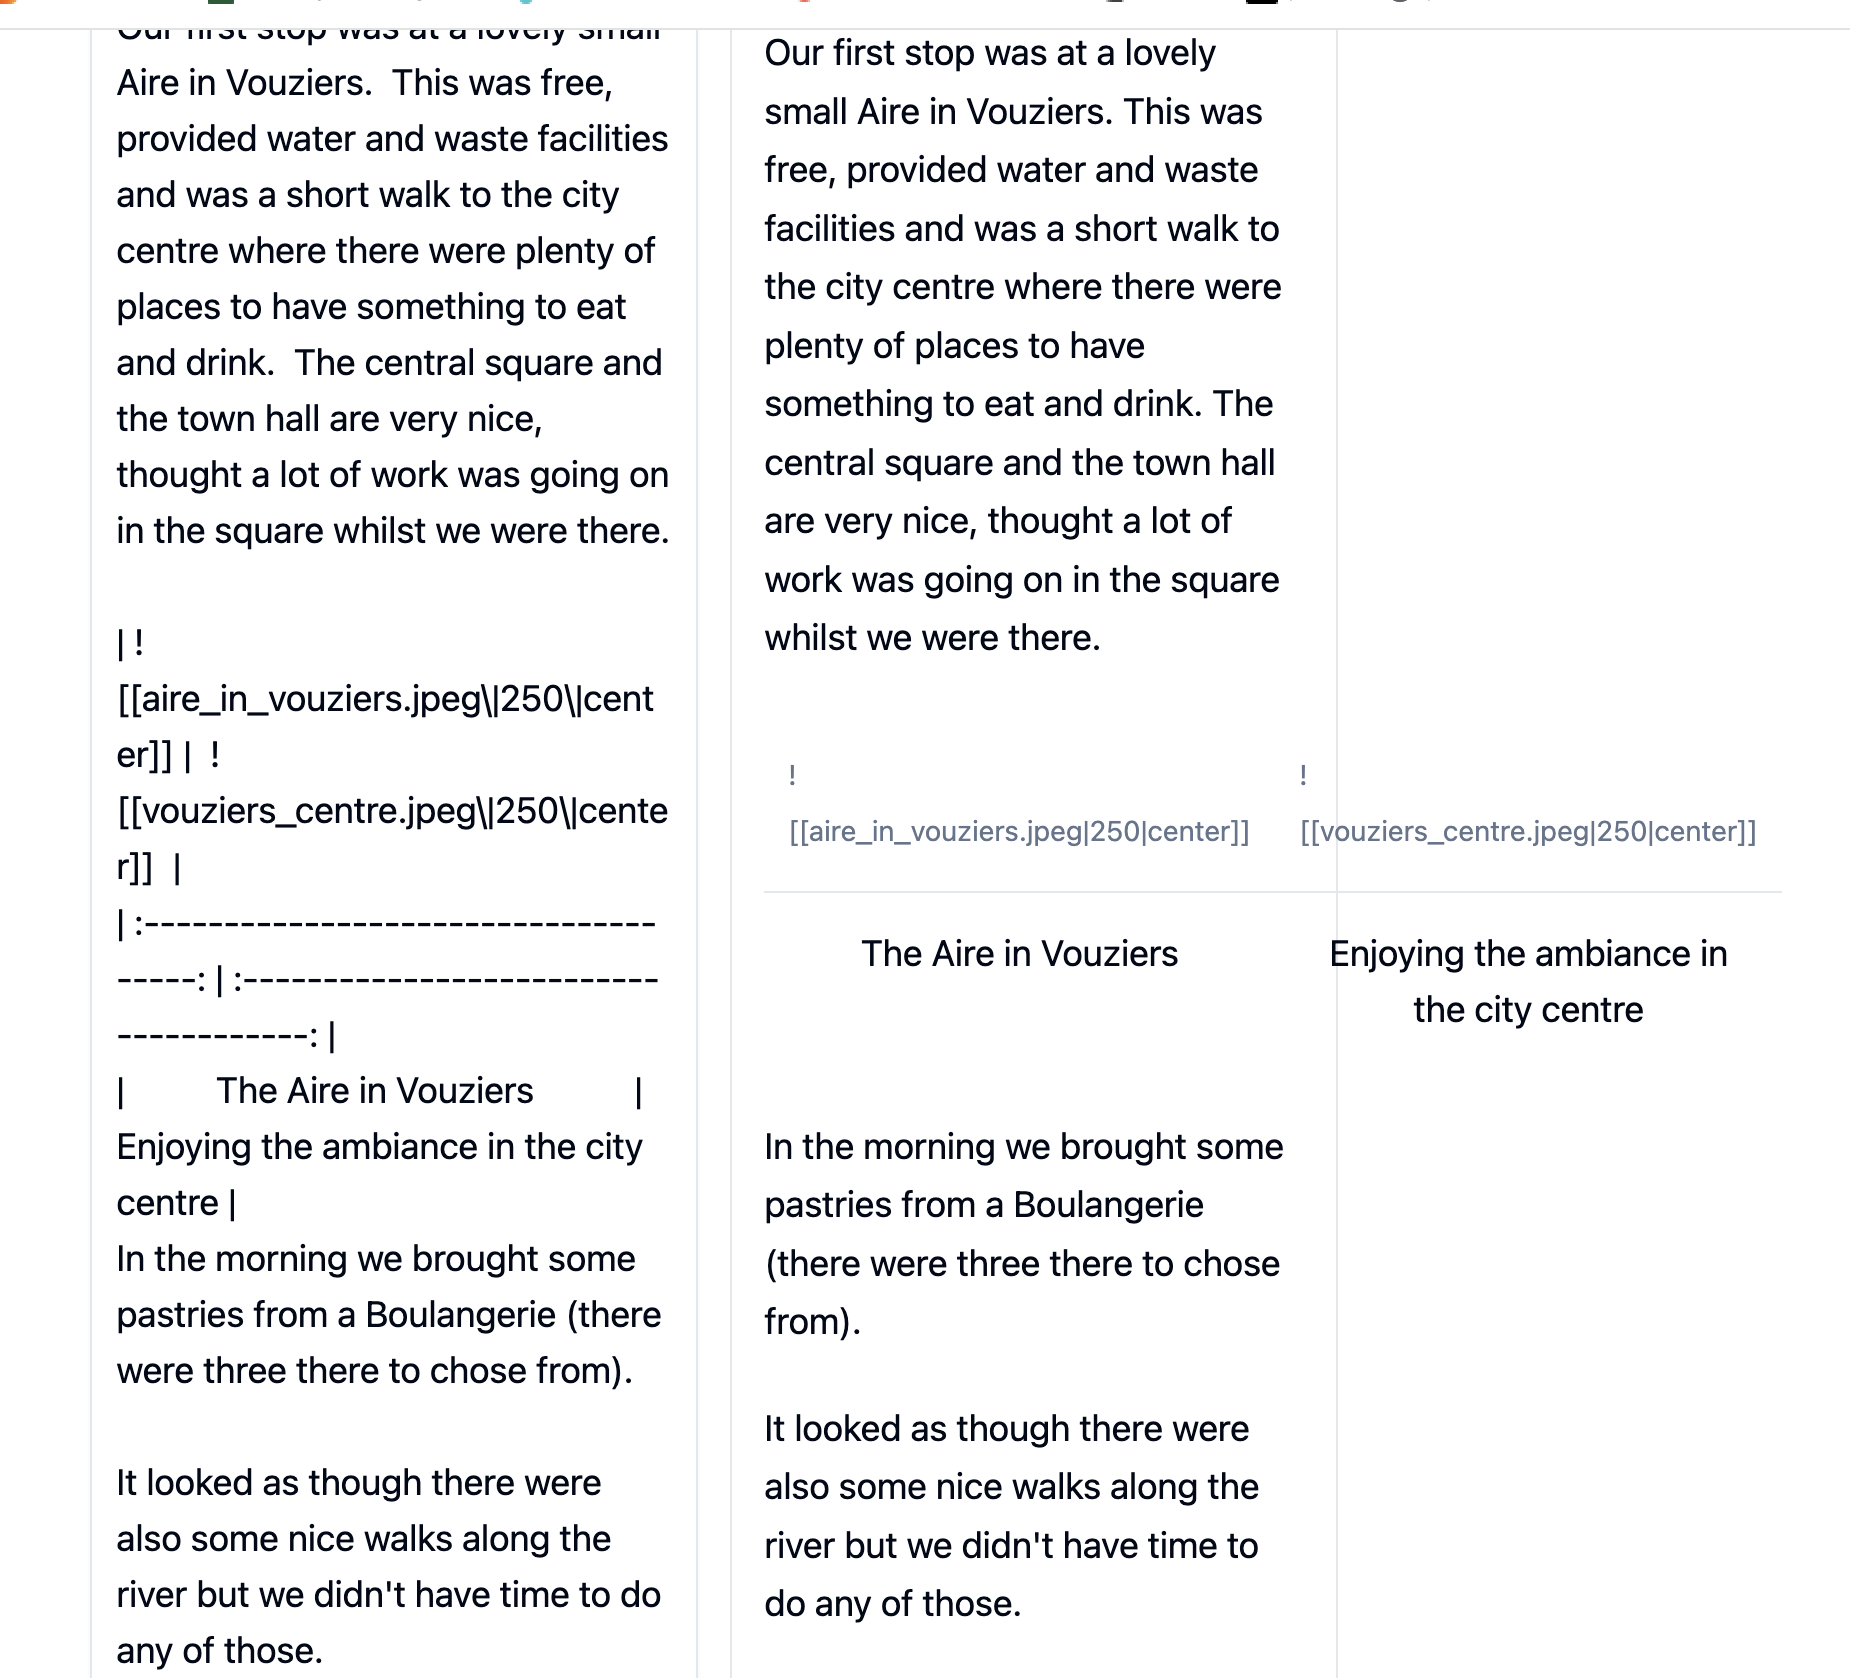


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me check how your `layout` function constrains the page width:

<details class='tool-usage-details'>
<summary>symsrc(sym='my_blog.core_v5.layout')</summary>

```json
{
  "id": "toolu_01JVMhZyTBHD4awjVjUMzmhe",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "my_blog.core_v5.layout"
    }
  },
  "result": "SymbolNotFound(Symbol 'my_blog' not found. Consider using `importmodule` first.)"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…yout" /app/data/my-blog/my_blo…</…>')</summary>

```json
{
  "id": "toolu_01NsVhnWFnbLnRgdKPisWw9o",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def layout\" /app/data/my-blog/my_blog/core_v5.py"
    }
  },
  "result": "189:def layout(*content, htmx, title=None):"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='/app/data/my-blog/my_blog/core_v5.py', nums=True, view_range=[189, 215])</summary>

```json
{
  "id": "toolu_01G6ung7eM5qNzBemGa9tjdT",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/app/data/my-blog/my_blog/core_v5.py",
      "nums": "True",
      "view_range": "[189, 215]"
    }
  },
  "result": "<TRUNCATED>\u2026layout(*content, htmx, title=None):\n   190 \u2502     if htmx and htmx.request: return (Title(title), *content)\n   191 \u2502     main = Main(*content, cls='w-full max-w-2xl mx-auto px-6 py-8 space-y-8', id=\"main-content\")\n   192 \u2502     return Title(title), Div(Div(navbar(), cls='max-w-2xl mx-auto px-4 mt-4'), main, footer(), cls=\"flex flex-col min-h-screen\")\n   193 \u2502 \n   194 \u2502 # %% ../nbs/05_blog_v5.ipynb #80c4cbeb\n   195 \u2502 def slug_exists(slug):\n   196 \u2502     if bool(list(state.posts_t.rows_where(\"slug = ?\", [slug], limit=1))):\n   197 \u2502         return list(state.posts_t.rows_where(\"slug = ?\", [slug], limit=1))[0]['id']\n   198 \u2502     else:\n   199 \u2502         return False\n   200 \u2502 \n   201 \u2502 # %% ../nbs/05_blog_v5.ipynb #954e2a1d\n   202 \u2502 def get_slug(title):\n   203 \u2502     slug = title.lower().replace(\" \", \"-\")\n   204 \u2502     slug = ''.join(c for c in slug if c.isalnum() or c == '-')[:60]\n   205 \u2502     return slug\n   206 \u2502 \n   207 \u2502 \n   208 \u2502 # %% ../nbs/05_blog_v5.ipynb #d14b4419\n   2\u2026</TRUNCATED>"
}
```

</details>

There's your constraint — line 191 has `max-w-2xl` on the main content, and line 192 has `max-w-2xl` on the navbar wrapper too. `max-w-2xl` is only 672px, which is fine for reading a blog post but very tight for a two-column editor.

The simplest approach is to pass an optional `cls` parameter to `layout` so the edit page can override the width. Alternatively, you could bypass `layout` entirely for the edit page and use a wider container.

For the image overflow, adding `overflow-hidden` or `overflow-x-auto` to the preview div would contain it.

Two small changes to your `post_edit` function should do it:

1. Add `overflow-x-auto` to your preview div: `cls='text-lg border rounded p-4 overflow-x-auto'`
2. For the width — would you prefer to modify `layout` to accept a custom width class, or build a separate wider layout for the edit page?
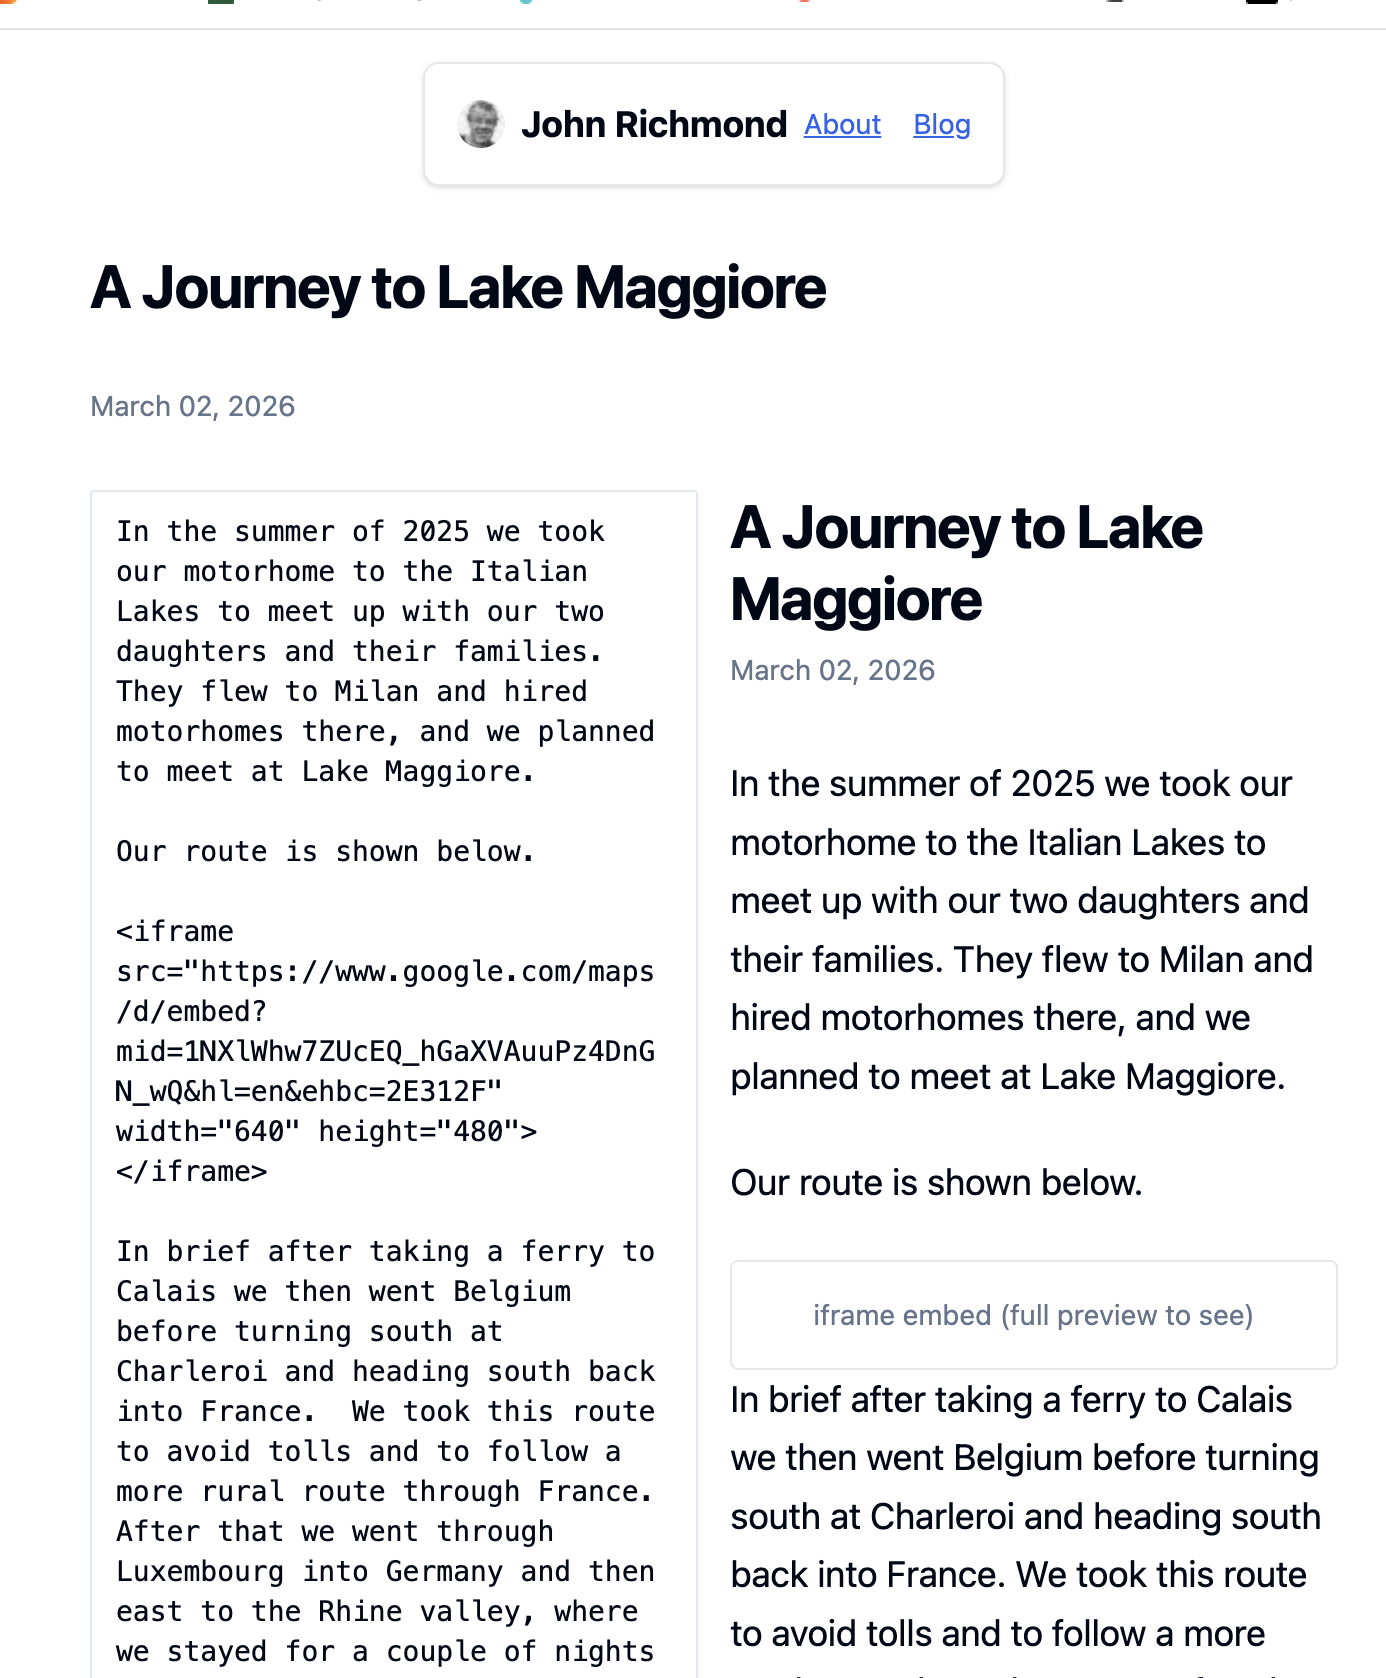

I think replacing layout with a version specifically for editing is most sensible.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Agreed — a dedicated `edit_layout` function makes sense. You can base it on the existing `layout` but swap `max-w-2xl` for something wider like `max-w-6xl` (1152px) or `max-w-7xl` (1280px), or even `max-w-full px-8` for nearly full width.

Have a go at creating `edit_layout` based on the existing `layout` function — the main changes are just the width classes on the `main` and navbar wrapper divs.

Thats working well, only issue is that when I cancel the htmx changes the main-content but the width remains high as it has not changed anything else apart from the div. What is the best way around that, do I need to force a full reload of the page?

Also, I need to now activate the save buttons, I am guessing i just need to overwrite the database entry with the new content, I don't think any other change are needed are they?

On a different topic, do I need to do anything to enable google analytics for the site? 

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Three separate topics — let's take them one at a time.

**Cancel button / width issue** — Yes, the problem is that HTMX only swaps `#main-content` but the parent div still has the wider classes from `edit_layout`. The simplest fix is to make Cancel do a full page redirect instead of an HTMX swap. Change the Cancel button to a regular link:

```python
A('Cancel', href=f'/blog/{slug}', cls=[ButtonT.secondary, ButtonT.sm])
```

That forces a full page load with the normal `layout` width.

Shall I move on to the save button question, or do you want to sort this one first?

Lets do the next one now as I can make the changes together

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠

**Save button** — Yes, the main thing is to update the database row with the new content and the `updated` timestamp. The key fields to update would be:

- `content` — the edited markdown
- `updated` — set to `datetime.now()`

You probably don't need to update `title`, `excerpt`, or `tags` here since those come from the frontmatter and you're editing the body content. Unless — are you planning to let users edit the frontmatter too, or just the post body?

If I use the format         
post = posts.update(dict(id=post_id, title=title, slug=slug, content=content, excerpt=excerpt, 
                                    created=datetime.now(), updated=datetime.now(), published=published))
If I leave out any of the items I presume these will just be left as is?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…date" /app/data/.local/lib/pyt…</…>')</summary>

```json
{
  "id": "toolu_01MBzf8ccgywSEnC8yTFzZKi",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def update\" /app/data/.local/lib/python3.12/site-packages/fastlite/core.py"
    }
  },
  "result": "/app/data/.local/lib/python3.12/site-packages/fastlite/core.py: No such file or directory (os error 2)"
}
```

</details>



<details class='tool-usage-details'>
<summary>importmodule(mod='fastlite')</summary>

```json
{
  "id": "toolu_01SEZmZ3gFhmQLyQKZXaDnrW",
  "call": {
    "function": "importmodule",
    "arguments": {
      "mod": "fastlite"
    }
  },
  "result": "None"
}
```

</details>



<details class='tool-usage-details'>
<summary>symsrc(sym='fastlite.core.MiniDataAPI.update')</summary>

```json
{
  "id": "toolu_011fEFKfgjCwr6MtdwHKLRD6",
  "call": {
    "function": "symsrc",
    "arguments": {
      "sym": "fastlite.core.MiniDataAPI.update"
    }
  },
  "result": "<TRUNCATED>\u2026-----------------------------------------------------------------\nAttributeError                            Traceback (most recent call last)\nCell In[21], line 2\n      1 import asyncio\n----> 2 __7ff54cca = symsrc(*(), **{'sym': 'fastlite.core.MiniDataAPI.update'})\n      3 if asyncio.iscoroutine(__7ff54cca): __7ff54cca = await __7ff54cca\n\nFile /usr/local/lib/python3.12/site-packages/toolslm/inspecttools.py:96, in symsrc(sym)\n     84 @llmtool\n     85 def symsrc(\n     86     sym: str  # Dotted symbol path (e.g `Interval` or `sympy.sets.sets.Interval`) or \"_last\" for previous result\n     87 ):\n     88     \"\"\"Get the source code for a symbol.\n     89 \n     90     Examples:\n   (...)     94     - `symsrc(\"_last\")` -> source of object from previous tool call\n     95     - For dispatchers or registries of callables: `symnth(\"module.dispatcher.funcs\", n) then symsrc(\"_last\")`\"\"\"\n---> 96     try: obj = resolve(sym)\n     97     except SymbolNotFound as e: return str(e)\n     98 \u2026</TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='<…>…pdate" /usr/local/lib/python3.…</…>')</summary>

```json
{
  "id": "toolu_01EDzNYMb3Qiz6NL9YHajK27",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-rn \"def update\" /usr/local/lib/python3.12/site-packages/fastlite/"
    }
  },
  "result": "/usr/local/lib/python3.12/site-packages/fastlite/kw.py:141:n(self:Table, updates: dict|None=None, pk_values: list|tuple|str|int|float|None=None,"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='<…>…/lib/python3.12/site-packages/…</…>', nums=True, view_range=[141, 175])</summary>

```json
{
  "id": "toolu_01FMTnfNKHvdPNv5BuUxkF9F",
  "call": {
    "function": "view",
    "arguments": {
      "path": "/usr/local/lib/python3.12/site-packages/fastlite/kw.py",
      "nums": "True",
      "view_range": "[141, 175]"
    }
  },
  "result": "<TRUNCATED>\u2026update(self:Table, updates: dict|None=None, pk_values: list|tuple|str|int|float|None=None,\n   142 \u2502            alter: bool=False, conversions: dict|None=None, xtra:dict|None=None, **kwargs) -> Any:\n   143 \u2502     if not updates: updates={}\n   144 \u2502     updates = _process_row(updates)\n   145 \u2502     if not xtra: xtra = getattr(self, 'xtra_id', {})\n   146 \u2502     updates = {**updates, **kwargs, **xtra}\n   147 \u2502     updates = _process_row(updates)\n   148 \u2502     if not updates: return {}\n   149 \u2502     if pk_values is None: pk_values = [updates[o] for o in self.pks]\n   150 \u2502     self._orig_update(pk_values, updates=updates, alter=alter, conversions=conversions)\n   151 \u2502     return self.get_last(legacy=False)\n   152 \u2502 \n   153 \u2502 \n   154 \u2502 @patch\n   155 \u2502 def insert_all(\n   156 \u2502     self:Table,\n   157 \u2502     records: Dict[str, Any]=None, pk=DEFAULT, foreign_keys=DEFAULT,\n   158 \u2502     column_order: Union[List[str], Default, None]=DEFAULT,\n   159 \u2502     not_null: Union[Iterable[str], \u2026</TRUNCATED>"
}
```

</details>

Yes, that's correct. The fastlite `update` only sets the fields you include in the dict — anything you leave out stays unchanged. So for a save you just need:

```python
posts.update(dict(id=post_id, content=content, updated=datetime.now()))
```

Ok so in the case of the save and continue I don't need to change the page but I guess it would be nice to add a toast to notify the user that the save has been made. If I don't want the save route to do anything to the main page do I just leave out the htmx and link parameters?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

You can use `hx-swap="none"` on the Save button — this tells HTMX to make the request but not swap anything into the page. Then to show a toast, you can return an `HX-Trigger` response header from your save route, which triggers a client-side event.

Alternatively, the simpler approach: target a small notification div and swap the toast into that:

```python
Button('Save', hx_post=f'/admin/save/{slug}', hx_target='#notify', hx_swap='innerHTML', cls=[ButtonT.primary, ButtonT.sm])
```

Then add a `Div(id='notify')` somewhere in your layout, and have the save route return a small success message that fades out. Which approach appeals to you?

How do I pass the updated content in the textarea to the save function. Can I load if from the form raw_post variable? I think I can also send variable using a htmx option as well but this seems easier?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes — since your Save button is inside the `Form` and the textarea has `name='raw_post'`, HTMX will automatically include all form fields in the POST request. So your save route just needs to accept `raw_post: str` and `slug: str` (from your hidden field) as parameters:

```python
@rt('/admin/save/{slug}')
def post(slug: str, raw_post: str):
```

PLease check save_post above.  When i want to save the post and then return to the normal view I could just change the target after running admin/save, would this work ok.  In this case I guess the Toast would not be shown as the div would not exist in the normal layout. How would you manage this?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

A few issues in `save_post`:

1. **Route syntax** — `@rt('/admin/save(htmx, slug, raw_post')` should be `@rt('/admin/save/{slug}')`
2. **`post_id` is undefined** — should be `p['id']`
3. **`content` is undefined** — should be `raw_post`

For **Save & Return** — rather than swapping content, you can return an `HX-Redirect` header which tells HTMX to do a full page navigation:

```python
return HttpHeader('HX-Redirect', f'/blog/{slug}')
```

Or in FastHTML you can use `RedirectResponse`. This avoids the toast problem entirely since the user lands on the fresh blog post page and can see their changes directly. Would that work for you?

I can see that either of te options for save and return could work but I need to build in a contingency for if the save does not work, as with the current save. My thinking is to do the same as the save route up to the point when the save is successful and then redirect to the blog page.  I could then adapt the save_post function to take a parameter saying whether to return to the normal mode or to continue in the edit mode.  DOes this make sense?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, that makes perfect sense. Add a `return_to_blog: bool = False` parameter — on failure show the error toast either way, on success either show the success toast (continue editing) or redirect (return to blog). Have a go at adapting your `save_post` to handle that.

Can you check the implementation of the buttons and the save function look ok now

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

A few issues I can spot:

1. **Missing `return`** in `save_post` — `RedirectResponse(f'/blog/{slug}')` needs `return` in front of it
2. **Missing `#notify` div** — the Save buttons target `#notify` but I don't see a `Div(id='notify')` anywhere in the `post_edit` form
3. **Cancel button** — we discussed changing this to a plain `A` tag for a full page reload (to reset the width), but it's still using `hx_get`
4. **Error toast** — you're using `AlertT.info` for errors too; `AlertT.warning` or `AlertT.error` would be more appropriate for the failure case

I have updated the functions.  To test here I should probably change @route to @rt and also import layout.  Is there anything else I need to do?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Yes, you'll also need to make sure `load_post`, `replace_iframe`, `replace_strava`, `render_md`, `EnhancedRenderer`, `process_obsidian_images`, and `process_strava_embeddings` are all available in the notebook. Most should already be imported from `core_v5`, but `load_post` is defined in a cell that I'm not sure has been run yet.

Also, your `post_edit` function had a couple of issues — the route decorator needs quotes around the path, and you reference `p` in the layout at the bottom but the variable is named `post`. Have you fixed those in your updated version?

still no luck


##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The iframe is trying to reach `localhost:8000` from your browser, but solveit runs in a container so `localhost` in the browser isn't the same as `localhost` inside the container. Let's test the route directly from within the notebook instead:

```python
from httpx import Client
c = Client(base_url='http://localhost:8000')
r = c.get('/admin/edit/a-journey-to-lake-maggiore')
print(r.status_code)
print(r.text[:500])
```

This will at least confirm the route is working, even if we can't render it in the iframe.

In [ ]:
from httpx import Client
c = Client(base_url='http://localhost:8000')
r = c.get('/admin/edit/a-journey-to-lake-maggiore')
print(r.status_code)
print(r.text[:500])

404
404 Not Found


In [ ]:
r = c.post('/auth/login', data={'username': 'admin', 'password': 'admin123'}, follow_redirects=True)
print(r.status_code)
r = c.get('/admin/edit/a-journey-to-lake-maggiore')
print(r.status_code)
print(r.text[:500])

User: User(id=1, username='admin', email='confusedjohn46@gmail.com', password='$2b$12$IU4RQZTO0QNoH1H4dcnF8u6zr7lArPxsr2N8LZfY9mXg35RSwsrna', role='admin', created_at='2026-02-24T17:08:39.103799', last_login='2026-03-10T19:30:34.603109', active=1)


200
404
404 Not Found


Ok, how do I make this display properly in the cell output

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
from IPython.display import HTML
HTML(r.text)
```

This will render the HTML inline in the cell output. It won't be perfect — external CSS/JS may not fully load — but it should give you a reasonable visual check of the structure and layout.

Is it better to use a div or a span for the button bar.  Also, I have used the Safe class for the preview area, do I need to have anything inside of that or can that act as a container in its own right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

**Div vs Span** — use `Div` for the button bar. `Div` is block-level (takes its own row), while `Span` is inline (flows with text). Buttons on their own line below the grid is definitely `Div`.

**Safe** — this is actually just a wrapper that tells FastHTML not to escape the HTML string. It doesn't render as a DOM element, so you can't give it an `id` for HTMX to target. You need a `Div(id='preview')` as the container, and then your preview endpoint returns the rendered HTML inside a `Safe()` which gets swapped into that div.

In my get_edit_layout function I need the function that handles '/admin/post_simple_render' to receive the current content of the 'raw_post' area.  Can it get this from the form data or do I need to find a way to explicitly pass it?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Since the textarea is inside a `Form`, HTMX will automatically include all form fields in the POST. The one thing to make sure is that your `Textarea` has a `name` attribute — HTMX sends form data based on `name`, not `id`. Then your handler can receive it directly as a parameter:

```python
def post_simple_render(raw_post: str):
```

So just add `name='raw_post'` to your Textarea alongside the `id`.

Ok will do, does the structure so far look sensible?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

The overall structure is good — Form wrapping a Grid with textarea and preview, plus a button bar below. A few things I've spotted:

1. **Syntax error** in the Grid `cls` — there's a missing closing quote: `cls='grid grid-cols-2 gap-4)` should be `cls='grid grid-cols-2 gap-4')`

2. **Cancel button** — `hx_get(f'/blog/post{slug}'` has wrong syntax. It should be `hx_get=f'/blog/{slug}'` (keyword argument, and check your URL pattern)

3. **Textarea** needs `name='raw_post'` as we just discussed, and you'll want to pass the initial content into it

4. **`get_edit_layout`** takes `htmx, slug` as params but `post_edit` calls it with no arguments

5. **`hx_trigger`** — `delay:200ms` alone isn't a complete trigger. You'd want something like `hx_trigger='keyup changed delay:1000ms'`

The `load_post` function looks solid. Want to fix these up and I'll review again?

In [ ]:
Ok those changes have been made.  

SyntaxError: invalid syntax (754622411.py, line 1)

In [ ]:
def edit_layout(*content, htmx, title=None):
    if htmx and htmx.request: return (Title(title), *content)
    main = Main(*content, cls='w-full max-w-full px-8 mx-auto py-8 space-y-8', id="main-content")
    return Title(title), Div(Div(navbar(), cls='max-w-full px-8 mx-auto mt-4'), main, footer(), cls="flex flex-col min-h-screen")